# Load packages and libraries

In [1]:
.libPaths()
.libPaths(new = c("/home/manuel.tardaguila/conda_envs/multiome_QC/lib/R/library"))
.libPaths()
# sessionInfo()

Sys.setenv(RETICULATE_PYTHON="/home/manuel.tardaguila/conda_envs/multiome_QC/bin/python")
library(reticulate)
reticulate::use_python("/home/manuel.tardaguila/conda_envs/multiome_QC/bin/python")
reticulate::use_condaenv("/home/manuel.tardaguila/conda_envs/multiome_QC")
reticulate::py_module_available(module='leidenalg')
reticulate::import('leidenalg')
suppressMessages(library("optparse"))
suppressMessages(library(hdf5r))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(EnsDb.Hsapiens.v86))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(Matrix))
suppressMessages(library(data.table))
suppressMessages(library(ggpubr))
suppressMessages(library(ggplot2))
suppressMessages(library(scDblFinder))
suppressMessages(library("tidyr"))
suppressMessages(library("tibble"))
suppressMessages(library("biovizBase"))
suppressMessages(library("patchwork"))
suppressMessages(library(glmGamPoi))
suppressMessages(library(SeuratData))
suppressMessages(library(SeuratDisk))
library(svglite)
library(RColorBrewer)




[1] "/home/manuel.tardaguila/R/x86_64-conda-linux-gnu-library/4.3"
[2] "/home/manuel.tardaguila/conda_envs/multiome_QC/lib/R/library"

[1] "/home/manuel.tardaguila/conda_envs/multiome_QC/lib/R/library"

[1] TRUE

Module(leidenalg)

Warning message:
“package ‘Seurat’ was built under R version 4.3.2”
Warning message:
“package ‘Signac’ was built under R version 4.3.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.2”
Warning message:
“package ‘IRanges’ was built under R version 4.3.2”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘Biobase’ was built under R version 4.3.2”
Warning message:
"package 'scDblFinder' was built under R version 4.3.2"
Warning message:
"package 'SingleCellExperiment' was built under R version 4.3.2"
Warning message:
"package 'SummarizedExperiment' was built under R version 4.3.2"
Warning message:
"package 'MatrixGenerics' was built under R version 4.3.2"
Warning message:
"package 'patchwork' was built under R version 4.3.3"
Warning message:
"package 'glmGamPoi' was built 

# Read objects already clustered and integrated

In [2]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

adata<-readRDS(file="merged_unprocessed_db_filt_clustered_minus_26_MACS2_peaks_HARMONY_clustered.rds")

In [ ]:
adata

# Recluster at lower resolution

In [5]:
### Modality WNN at 1 resolution

adata <- FindClusters(adata, graph.name='wsnn', algorithm=4, resolution = 0.25, verbose=FALSE, method = "igraph")

Warning message in paste(el[, 1], el[, 2], sep = "|"):
"NAs introduced by coercion to integer range"
Warning message in paste(el[, 1], el[, 2], sep = "|"):
"NAs introduced by coercion to integer range"
Warning message in deparse(substitute(arg)):
"NAs introduced by coercion to integer range"
Warning message in paste0("igraph::", x):
"NAs introduced by coercion to integer range"
Warning message in deparse(x[[1L]]):
"NAs introduced by coercion to integer range"
Warning message in deparse(expr, width.cutoff, ...):
"NAs introduced by coercion to integer range"
Warning message in paste(deparse(expr, width.cutoff, ...), collapse = collapse):
"NAs introduced by coercion to integer range"
Warning message in deparse(x[[1L]]):
"NAs introduced by coercion to integer range"
Warning message in deparse(expr, width.cutoff, ...):
"NAs introduced by coercion to integer range"
Warning message in paste(deparse(expr, width.cutoff, ...), collapse = collapse):
"NAs introduced by coercion to integer range"
W

# Read the file with the genotypes and filter by minimum number of UMIs supporting the genotyped Bc

In [6]:
Uniquely_genotyped_larry_barcodes_assignments<-readRDS("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/deconvolute_LARRY/count_and_filter/Uniquely_genotyped_larry_barcodes_assignments.rds")

In [7]:
Threshold_UMIS_per_cell = 3

In [8]:
Uniquely_genotyped_larry_barcodes_assignments_FILTERED<-Uniquely_genotyped_larry_barcodes_assignments[which(Uniquely_genotyped_larry_barcodes_assignments$Number_of_UMIS >= Threshold_UMIS_per_cell),]

In [9]:
cat("Uniquely_genotyped_larry_barcodes_assignments_FILTERED\n")
  cat(str(Uniquely_genotyped_larry_barcodes_assignments_FILTERED))
  cat("\n")

Uniquely_genotyped_larry_barcodes_assignments_FILTERED
'data.frame':	5435 obs. of  5 variables:
 $ sample           : Ord.factor w/ 4 levels "MCO_01326"<"MCO_01327"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ CellBC           : chr  "CB:Z:AGTAATGCATTGCAGC-1" "CB:Z:CTAGCTTGTGAGCGAA-1" "CB:Z:CTTACCGGTAAAGCGG-1" "CB:Z:CTTACTAGTCTTTATG-1" ...
 $ GFPbc            : Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 1 1 1 1 1 1 2 2 2 2 ...
 $ GFPbc_attribution: int  1 1 1 1 1 1 1 1 1 1 ...
 $ Number_of_UMIS   : int  3 3 3 3 4 6 3 12 5 5 ...



In [10]:
Uniquely_genotyped_larry_barcodes_assignments_FILTERED$Sample_CellBC_adapted<-paste(Uniquely_genotyped_larry_barcodes_assignments_FILTERED$sample,
                                                                                    gsub("^[^:]+:[^:]+:","",Uniquely_genotyped_larry_barcodes_assignments_FILTERED$CellBC), sep='_')

cat("Uniquely_genotyped_larry_barcodes_assignments_sel_FILTERED_1\n")
cat(str(Uniquely_genotyped_larry_barcodes_assignments_FILTERED))
cat("\n")

Uniquely_genotyped_larry_barcodes_assignments_sel_FILTERED_1
'data.frame':	5435 obs. of  6 variables:
 $ sample               : Ord.factor w/ 4 levels "MCO_01326"<"MCO_01327"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ CellBC               : chr  "CB:Z:AGTAATGCATTGCAGC-1" "CB:Z:CTAGCTTGTGAGCGAA-1" "CB:Z:CTTACCGGTAAAGCGG-1" "CB:Z:CTTACTAGTCTTTATG-1" ...
 $ GFPbc                : Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 1 1 1 1 1 1 2 2 2 2 ...
 $ GFPbc_attribution    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ Number_of_UMIS       : int  3 3 3 3 4 6 3 12 5 5 ...
 $ Sample_CellBC_adapted: chr  "MCO_01326_AGTAATGCATTGCAGC-1" "MCO_01326_CTAGCTTGTGAGCGAA-1" "MCO_01326_CTTACCGGTAAAGCGG-1" "MCO_01326_CTTACTAGTCTTTATG-1" ...



# Add the genotype data to my object

In [11]:
### Add GFPbc_attribution

gfp1      = setNames(Uniquely_genotyped_larry_barcodes_assignments_FILTERED$GFPbc_attribution, 
                     Uniquely_genotyped_larry_barcodes_assignments_FILTERED$Sample_CellBC_adapted)

cat("gfp1_0\n")
cat(str(gfp1))
cat("\n")


adata@meta.data$No_assigned_GFPbc = gfp1[rownames(adata@meta.data)]

### Add GFPbc

gfp2      = setNames(as.character(Uniquely_genotyped_larry_barcodes_assignments_FILTERED$GFPbc), 
                     Uniquely_genotyped_larry_barcodes_assignments_FILTERED$Sample_CellBC_adapted)

#cat("gfp2_0\n")
#cat(str(gfp2))
#cat("\n")


adata@meta.data$Assigned_GFPbc = gfp2[rownames(adata@meta.data)]


metadata_adata<-adata[[]]

#cat("metadata_adata_REDEFINED_AFTER_GFPbc_assignation\n")
#cat(str(metadata_adata))
#cat("\n")


adata@meta.data$Assigned_GFPgenotype<-NA

adata@meta.data$Assigned_GFPgenotype[which(adata@meta.data$Assigned_GFPbc%in%c("chrGFP_WTA","chrGFP_WTB","chrGFP_WTC"))]<-'WT'
adata@meta.data$Assigned_GFPgenotype[which(adata@meta.data$Assigned_GFPbc%in%c("chrGFP_rs1","chrGFP_rs2","chrGFP_rs3"))]<-'rsCHEK2'
adata@meta.data$Assigned_GFPgenotype[which(adata@meta.data$Assigned_GFPbc%in%c("chrGFP_R882H1","chrGFP_R882H2","chrGFP_R882H3"))]<-'R882H'
adata@meta.data$Assigned_GFPgenotype[which(adata@meta.data$Assigned_GFPbc%in%c("chrGFP_rs_R882H1","chrGFP_rs_R882H2","chrGFP_rs_R882H3"))]<-'Double_mutants'

metadata_adata<-adata[[]]

#cat("metadata_adata_REDEFINED_AFTER_Assigned_GFPgenotype_assignation\n")
#cat(str(metadata_adata))
#cat("\n")

adata@meta.data$Assigned_GFPbc<-factor(adata@meta.data$Assigned_GFPbc,
                                       levels = c("chrGFP_WTA","chrGFP_WTB","chrGFP_WTC",
                                                  "chrGFP_rs1","chrGFP_rs2","chrGFP_rs3",
                                                  "chrGFP_R882H1","chrGFP_R882H2","chrGFP_R882H3",
                                                  "chrGFP_rs_R882H1","chrGFP_rs_R882H2","chrGFP_rs_R882H3","No_GFPbcs"),
                                       ordered=T)



adata@meta.data$Assigned_GFPgenotype<-factor(adata@meta.data$Assigned_GFPgenotype,
                                             levels = c("WT","rsCHEK2","R882H","Double_mutants"),
                                             ordered=T)


metadata_adata<-adata[[]]

#cat("metadata_adata_REDEFINED_FINAL\n")
#cat(str(metadata_adata))
#cat("\n")

gfp1_0
 Named int [1:5435] 1 1 1 1 1 1 1 1 1 1 ...
 - attr(*, "names")= chr [1:5435] "MCO_01326_AGTAATGCATTGCAGC-1" "MCO_01326_CTAGCTTGTGAGCGAA-1" "MCO_01326_CTTACCGGTAAAGCGG-1" "MCO_01326_CTTACTAGTCTTTATG-1" ...



In [12]:
summary(adata@meta.data$Assigned_GFPbc)

chrGFP_WTA       chrGFP_WTB       chrGFP_WTC       chrGFP_rs1 
              14               20               36              118 
      chrGFP_rs2       chrGFP_rs3    chrGFP_R882H1    chrGFP_R882H2 
             134             1629              105                9 
   chrGFP_R882H3 chrGFP_rs_R882H1 chrGFP_rs_R882H2 chrGFP_rs_R882H3 
             109              236               79               80 
       No_GFPbcs             NA's 
               0            34935

In [13]:
summary(adata@meta.data$Assigned_GFPgenotype)

WT        rsCHEK2          R882H Double_mutants           NA's 
            70           1881            223            395          34935

# Read the predictions from cell typist

In [14]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

In [17]:
cell_typist_BMA<-read.csv(file="Hannifa_celltypist_prediction.csv")

In [22]:
#str(cell_typist_BMA)

In [23]:
str(row.names(cell_typist_BMA))

 chr [1:37504] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


In [24]:
row.names(cell_typist_BMA)<-cell_typist_BMA$X

In [25]:
cell_typist_BMA_subset<-cell_typist_BMA[,c(which(colnames(cell_typist_BMA) %in% c("predicted_labels","conf_score")))]

In [27]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_BMA_subset$predicted_labels,
  col.name = 'CellTypist_BMA_label'
)

In [28]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_BMA_subset$conf_score,
  col.name = 'CellTypist_BMA_conf_score'
)

In [29]:
cell_typist_IPSCs<-read.csv(file="Alsinet_celltypist_prediction.csv")

In [30]:
str(row.names(cell_typist_IPSCs))

 chr [1:37504] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


In [31]:
row.names(cell_typist_IPSCs)<-cell_typist_IPSCs$X

In [32]:
cell_typist_IPSCs_subset<-cell_typist_IPSCs[,c(which(colnames(cell_typist_IPSCs) %in% c("predicted_labels","conf_score")))]

In [33]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_IPSCs_subset$predicted_labels,
  col.name = 'CellTypist_IPSCs_label'
)

In [34]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_IPSCs_subset$conf_score,
  col.name = 'CellTypist_IPSCs_conf_score'
)

## check

In [46]:
check_df<-merge(cell_typist_BMA, cell_typist_IPSCs, by="X")

In [50]:
#str(check_df)

In [51]:
#colnames(check_df)

In [53]:
indx.rows<-which((check_df$X)%in%c('MCO_01326_AAACAGCCACAGCCAT-1','MCO_01326_AAAGCGGGTTCAAGCA-1','MCO_01326_ACAGTATGTGAGCGAA-1','MCO_01326_GTTTAGCAGACAACGA-1','MCO_01329_CCCTCACCAGCTTACA-1'))
indx.rows

[1]     1   100  1000 10000 30000

In [55]:
indx.cols<-which(colnames(check_df)%in%c('predicted_labels.x','predicted_labels.y'))
indx.cols

[1]  67 134

In [56]:
check_df[indx.rows,indx.cols]

,predicted_labels.x,predicted_labels.y
,<chr>,<chr>
1,DC3,iPSCs
100,DC3,iPSCs
1000,monocytoid macrophage,EarlyFibroblasts
10000,myelocyte,EarlyFibroblasts
30000,late erythroid,Megakaryocytes


In [57]:
met<-adata[[]]
indx.rows<-which(row.names(met)%in%c('MCO_01326_AAACAGCCACAGCCAT-1','MCO_01326_AAAGCGGGTTCAAGCA-1','MCO_01326_ACAGTATGTGAGCGAA-1','MCO_01326_GTTTAGCAGACAACGA-1','MCO_01329_CCCTCACCAGCTTACA-1'))
indx.rows

[1]     1   100  1000 10000 30000

In [58]:
met$CellTypist_BMA_label[indx.rows]

[1] "DC3"                   "DC3"                   "monocytoid macrophage"
[4] "myelocyte"             "late erythroid"

In [59]:
met$CellTypist_IPSCs_label[indx.rows]

[1] "iPSCs"            "iPSCs"            "EarlyFibroblasts" "EarlyFibroblasts"
[5] "Megakaryocytes"

## Filter cell typist BMA by frequency of label and majority voting within a cluster

In [75]:
met.dt<-data.table(met, key=c("CellTypist_BMA_label","seurat_clusters"))
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [76]:
met.dt<-data.table(met, key=c("seurat_clusters"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [77]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by="seurat_clusters")
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [78]:
met.dt<-data.table(met, key=c("CellTypist_BMA_label"))
Freq.table_BMA<-as.data.frame(met.dt[,.(Freq_BMA=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.table_BMA,
                  by="CellTypist_BMA_label")

#Freq.table

### Filter BMA annotations that have  more than 100 cells and make more than 15% of any cluster

In [217]:
Freq.table_filtered_BMA<-Freq.table[which(Freq.table$Perc >= 15 & Freq.table$Freq_BMA >= 100),]

In [218]:
str(Freq.table_filtered_BMA)

'data.frame':	24 obs. of  6 variables:
 $ CellTypist_BMA_label: chr  "DC3" "DC3" "DC3" "early erythroid" ...
 $ seurat_clusters     : Factor w/ 18 levels "1","2","3","4",..: 10 11 2 8 9 10 2 15 3 6 ...
 $ Freq                : int  226 211 1427 730 190 176 1251 352 3216 1179 ...
 $ TOTAL               : int  1046 983 6310 1334 1103 1046 6310 391 4501 1427 ...
 $ Perc                : num  21.6 21.5 22.6 54.7 17.2 ...
 $ Freq_BMA            : int  4094 4094 4094 1839 2055 2245 2445 8499 8499 8499 ...


In [219]:
summary(droplevels(interaction(Freq.table_filtered_BMA$CellTypist_BMA_label,Freq.table_filtered_BMA$seurat_clusters)))

myelocyte.1   schwann cells.1             DC3.2             MEP.2 
                1                 1                 1                 1 
             MK.3              MK.4       myelocyte.5              MK.6 
                1                 1                 1                 1 
             MK.7 early erythroid.8        early MK.9              MK.9 
                1                 1                 1                 1 
           DC3.10 late erythroid.10            DC3.11         tip EC.12 
                1                 1                 1                 1 
     myelocyte.13             MK.14             MK.15      myelocyte.16 
                1                 1                 1                 1 
 schwann cells.16             MK.17      myelocyte.18  schwann cells.18 
                1                 1                 1                 1

#### Add them to the metadata

In [220]:
adata@meta.data<-adata@meta.data[,-which(colnames(adata@meta.data)%in%c('CellTypist_BMA_FILTERED','CellTypist_BMA_label_filtered'))]

In [221]:
met<-adata[[]]

In [222]:
#colnames(met)

In [223]:
str(row.names(met))

 chr [1:37504] "MCO_01326_AAACAGCCACAGCCAT-1" ...


In [224]:
met$CellID<-row.names(met)

In [225]:
met<-merge(met,Freq.table_filtered_BMA, by=c("CellTypist_BMA_label","seurat_clusters"))

In [226]:
selected_cells_BMA<-met$CellID[!is.na(met$Freq_BMA)]

str(selected_cells_BMA)

 chr [1:19584] "MCO_01328_TGCTTCCAGCATCCAG-1" ...


In [227]:
adata@meta.data$CellTypist_BMA_label_filtered<-NA

In [228]:
indx.cells<-which(row.names(adata@meta.data)%in%selected_cells_BMA)

str(indx.cells)

 int [1:19584] 3 8 9 10 11 13 15 16 18 19 ...


In [229]:
adata@meta.data$CellTypist_BMA_label_filtered[indx.cells]<-adata@meta.data$CellTypist_BMA_label[indx.cells]

In [230]:
summary(as.factor(adata@meta.data$CellTypist_BMA_label_filtered))

DC3 early erythroid        early MK  late erythroid             MEP 
           1864             730             190             176            1251 
             MK       myelocyte   schwann cells          tip EC            NA's 
           7800            5019            2225             329           17920

In [231]:
indx.KEEP<-!is.na(adata$CellTypist_BMA_label_filtered)

In [232]:
summary(droplevels(interaction(adata$CellTypist_BMA_label_filtered[indx.KEEP],adata$seurat_clusters[indx.KEEP])))

myelocyte.1   schwann cells.1             DC3.2             MEP.2 
             4288              2127              1427              1251 
             MK.3              MK.4       myelocyte.5              MK.6 
             3216               794               378              1179 
             MK.7 early erythroid.8        early MK.9              MK.9 
             1317               730               190               181 
           DC3.10 late erythroid.10            DC3.11         tip EC.12 
              226               176               211               329 
     myelocyte.13             MK.14             MK.15      myelocyte.16 
              177               402               352                85 
 schwann cells.16             MK.17      myelocyte.18  schwann cells.18 
               56               359                91                42

## Filter cell typist IPSC by frequency of label and majority voting within a cluster

In [242]:
met<-adata[[]]

In [243]:
#colnames(met)

In [244]:
met.dt<-data.table(met, key=c("CellTypist_IPSCs_label","seurat_clusters"))
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [245]:
met.dt<-data.table(met, key=c("seurat_clusters"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [246]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by="seurat_clusters")
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [247]:
met.dt<-data.table(met, key=c("CellTypist_IPSCs_label"))
Freq.table_IPSC<-as.data.frame(met.dt[,.(Freq_IPSC=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.table_IPSC,
                  by="CellTypist_IPSCs_label")

#Freq.table

### Filter IPSC annotations that have  more than 100 cells and make more than 15% of any cluster

In [248]:
Freq.table_filtered_IPSC<-Freq.table[which(Freq.table$Perc >= 15 & Freq.table$Freq_IPSC >= 100),]

In [249]:
str(Freq.table_filtered_IPSC)

'data.frame':	27 obs. of  6 variables:
 $ CellTypist_IPSCs_label: chr  "EmergentMesoderm" "ErythrocyteLineage" "HemogenicEndothelium" "iPSCs" ...
 $ seurat_clusters       : Factor w/ 18 levels "1","2","3","4",..: 16 8 12 1 18 5 13 16 7 9 ...
 $ Freq                  : int  83 270 361 5770 141 654 153 83 1372 551 ...
 $ TOTAL                 : int  372 1334 824 10771 248 1474 452 372 1372 1103 ...
 $ Perc                  : num  22.3 20.2 43.8 53.6 56.9 ...
 $ Freq_IPSC             : int  262 454 506 6948 6948 6948 6948 6948 22133 22133 ...


In [253]:
summary(droplevels(interaction(Freq.table_filtered_IPSC$CellTypist_IPSCs_label,Freq.table_filtered_IPSC$seurat_clusters)))

iPSCs.1       PrimitiveStreak.1        Megakaryocytes.2 
                      1                       1                       1 
       Megakaryocytes.3        Megakaryocytes.4                 iPSCs.5 
                      1                       1                       1 
      PrimitiveStreak.5        Megakaryocytes.6        Megakaryocytes.7 
                      1                       1                       1 
   ErythrocyteLineage.8        Megakaryocytes.8        Megakaryocytes.9 
                      1                       1                       1 
      PrimitiveStreak.9       Megakaryocytes.10       Megakaryocytes.11 
                      1                       1                       1 
HemogenicEndothelium.12       Megakaryocytes.12                iPSCs.13 
                      1                       1                       1 
     PrimitiveStreak.13       Megakaryocytes.14       Megakaryocytes.15 
                      1                       1                       1 
    EmergentMesoderm.16                iPSCs.16          NeuralCrest.16 
                      1                       1                       1 
      Megakaryocytes.17                iPSCs.18      PrimitiveStreak.18 
                      1                       1                       1

#### Add them to the metadata

In [254]:
#adata@meta.data<-adata@meta.data[,-which(colnames(adata@meta.data)%in%c('CellTypist_BMA_FILTERED','CellTypist_BMA_label_filtered'))]

In [255]:
met<-adata[[]]

In [256]:
#colnames(met)

In [257]:
str(row.names(met))

 chr [1:37504] "MCO_01326_AAACAGCCACAGCCAT-1" ...


In [258]:
met$CellID<-row.names(met)

In [259]:
met<-merge(met,Freq.table_filtered_IPSC, by=c("CellTypist_IPSCs_label","seurat_clusters"))

In [260]:
selected_cells_IPSC<-met$CellID[!is.na(met$Freq_IPSC)]

str(selected_cells_IPSC)

 chr [1:34414] "MCO_01326_AAGCATGAGCACCACA-1" ...


In [261]:
adata@meta.data$CellTypist_IPSCs_label_filtered<-NA

In [262]:
indx.cells<-which(row.names(adata@meta.data)%in%selected_cells_IPSC)

str(indx.cells)

 int [1:34414] 1 3 5 6 7 8 9 10 11 13 ...


In [263]:
adata@meta.data$CellTypist_IPSCs_label_filtered[indx.cells]<-adata@meta.data$CellTypist_IPSCs_label[indx.cells]

In [264]:
summary(as.factor(adata@meta.data$CellTypist_IPSCs_label_filtered))

EmergentMesoderm   ErythrocyteLineage HemogenicEndothelium 
                  83                  270                  361 
               iPSCs       Megakaryocytes          NeuralCrest 
                6801                22077                   80 
     PrimitiveStreak                 NA's 
                4742                 3090

In [265]:
indx.KEEP<-!is.na(adata$CellTypist_IPSCs_label_filtered)

In [266]:
summary(droplevels(interaction(adata$CellTypist_IPSCs_label_filtered[indx.KEEP],adata$seurat_clusters[indx.KEEP])))

iPSCs.1       PrimitiveStreak.1        Megakaryocytes.2 
                   5770                    3718                    6235 
       Megakaryocytes.3        Megakaryocytes.4                 iPSCs.5 
                   4501                    3874                     654 
      PrimitiveStreak.5        Megakaryocytes.6        Megakaryocytes.7 
                    468                    1424                    1372 
   ErythrocyteLineage.8        Megakaryocytes.8        Megakaryocytes.9 
                    270                    1043                     551 
      PrimitiveStreak.9       Megakaryocytes.10       Megakaryocytes.11 
                    228                     757                     976 
HemogenicEndothelium.12       Megakaryocytes.12                iPSCs.13 
                    361                     172                     153 
     PrimitiveStreak.13       Megakaryocytes.14       Megakaryocytes.15 
                    260                     419                     391 
    EmergentMesoderm.16                iPSCs.16          NeuralCrest.16 
                     83                      83                      80 
      Megakaryocytes.17                iPSCs.18      PrimitiveStreak.18 
                    362                     141                      68

# Create a time variable

In [267]:
adata$time_point<-NA

adata$time_point[which(adata$orig.ident == "MCO_01326")]<-'Day_0'
adata$time_point[which(adata$orig.ident == "MCO_01327")]<-'Day_8'
adata$time_point[which(adata$orig.ident == "MCO_01328")]<-'Day_12'
adata$time_point[which(adata$orig.ident == "MCO_01329")]<-'Day_15'


adata$time_point<-factor(adata$time_point,
                        levels=c('Day_0','Day_8','Day_12','Day_15'),
                        ordered=T)




In [268]:
adata$time<-NA

adata$time[which(adata$orig.ident == "MCO_01326")]<-0
adata$time[which(adata$orig.ident == "MCO_01327")]<-8*24
adata$time[which(adata$orig.ident == "MCO_01328")]<-12*24
adata$time[which(adata$orig.ident == "MCO_01329")]<-15*24



# SAVE object with new clusters, genotype added and cell typist info added

In [269]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")
saveRDS(adata, file="merged_unprocessed_db_filt_clustered_minus_26_MACS2_peaks_HARMONY_clustered_LOWER_RES_clusters_CT.rds")

# Read objects already clustered and integrated with new clusters

In [270]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

adata<-readRDS(file="merged_unprocessed_db_filt_clustered_minus_26_MACS2_peaks_HARMONY_clustered_LOWER_RES_clusters_CT.rds")

# Gaphs

## new path_graphs

In [272]:
path_graphs<-"/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/graphs_FINAL_presentation"

In [273]:
if (file.exists(path_graphs)){

    }else{

    dir.create(path_graphs)
    }

## Wnn graphs 

### Sample_ID

png 
  2

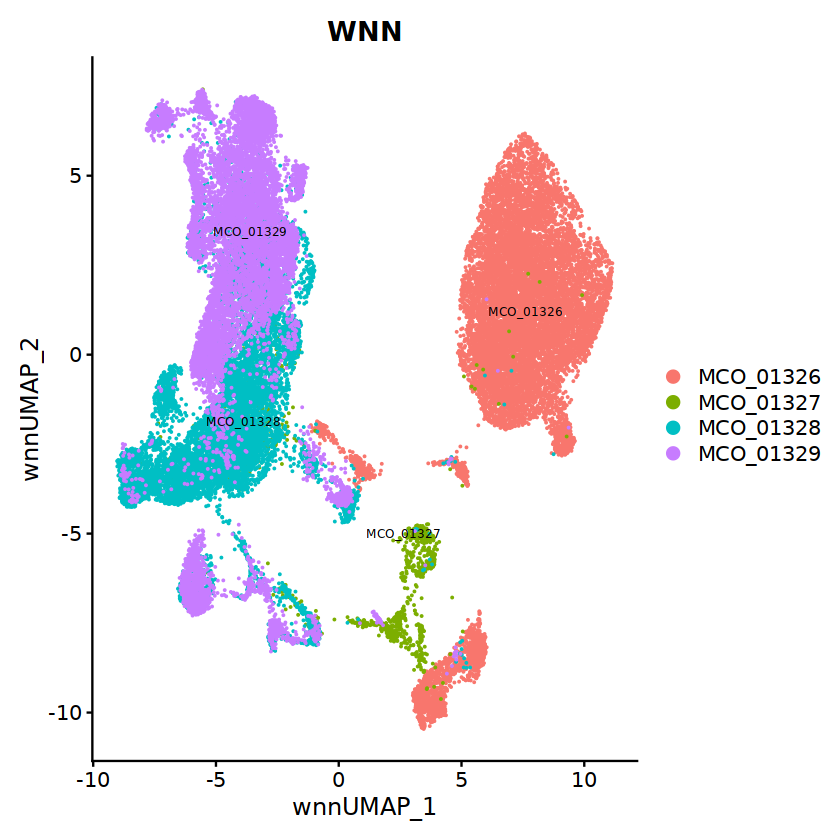

In [277]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "orig.ident", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3
setwd(path_graphs)
png(file='WNN_by_seurat_clusters_SampleID.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

### clusters

png 
  2

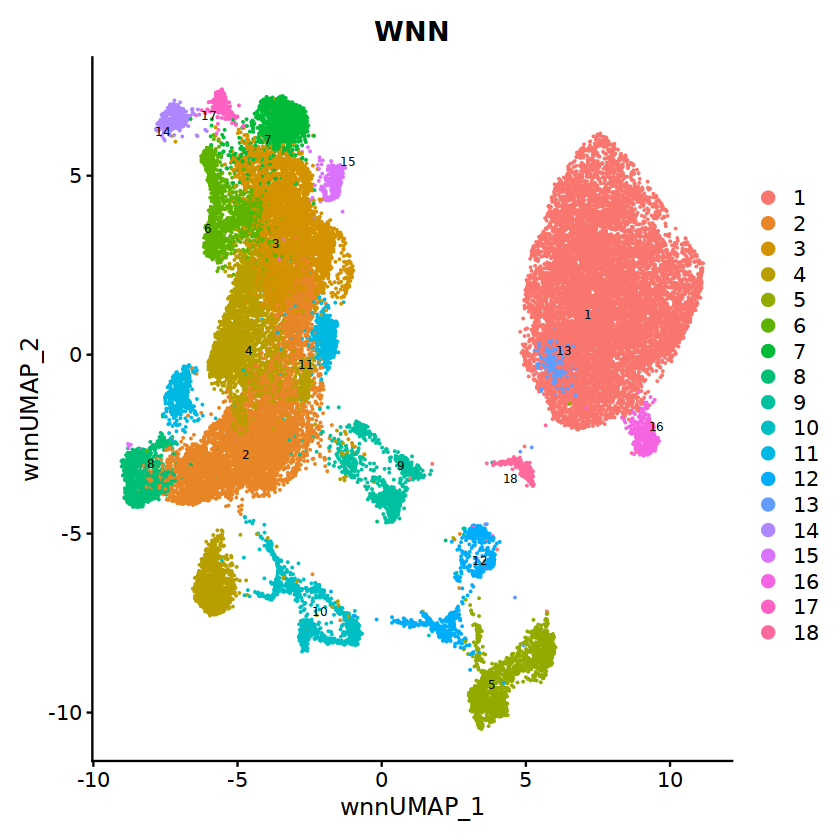

In [275]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "seurat_clusters", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3
setwd(path_graphs)
png(file='WNN_by_seurat_clusters.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

### Marker genes

png 
  2

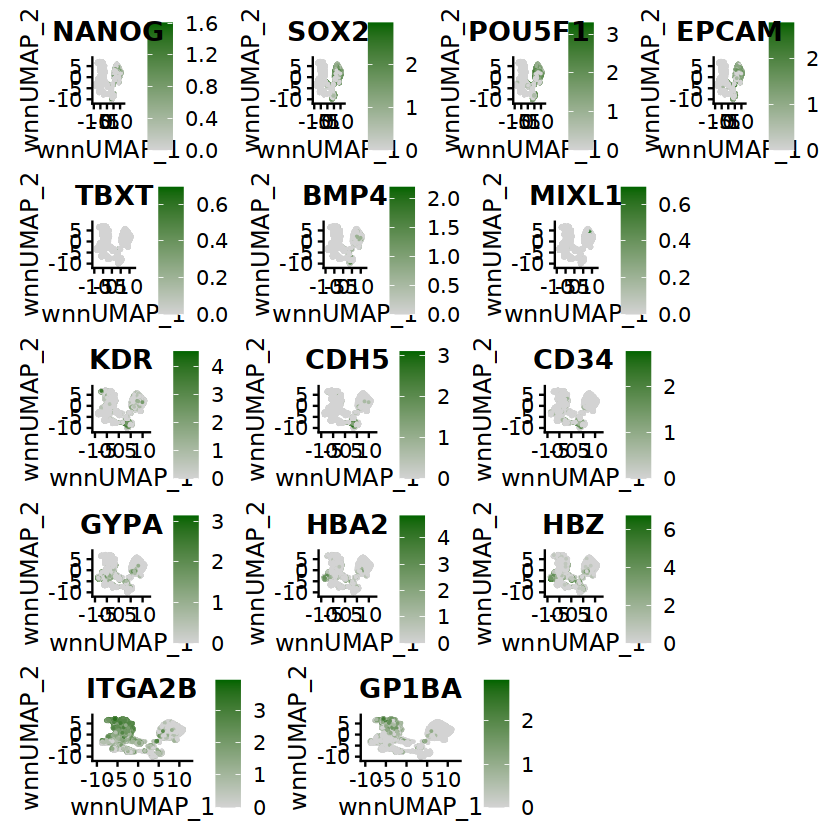

In [276]:
## Graph WNN by marker genes

DefaultAssay(adata) <- 'SCT'


p5 <- FeaturePlot(adata, features = c("NANOG",'SOX2','POU5F1','EPCAM'),
                  reduction = 'umap.wnn', 
                  cols = c("lightgrey","darkgreen"), ncol = 4)

p5_A <- FeaturePlot(adata, features = c("TBXT",'BMP4','MIXL1'),
                  reduction = 'umap.wnn', 
                  cols = c("lightgrey","darkgreen"), ncol = 4)
p5_B <- FeaturePlot(adata, features = c("KDR",'CDH5','CD34'),
                  reduction = 'umap.wnn', 
                  cols = c("lightgrey","darkgreen"), ncol = 4)
p5_1 <- FeaturePlot(adata, features = c('GYPA','HBA2','HBZ'),
                    reduction = 'umap.wnn', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)
p5_2 <- FeaturePlot(adata, features = c('ITGA2B','GP1BA'),
                    reduction = 'umap.wnn', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)

p5 / p5_A / p5_B / p5_1 / p5_2

setwd(path_graphs)
png(file='WNN_marker_genes.png', width =1000, height = 1000)
p5 / p5_A / p5_B / p5_1 / p5_2
dev.off()


### CellTypist_BMA_label_filtered

In [284]:
colnames(adata[[]])

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "wsnn_res.0.25"                     "CellTypist_BMA_label"             
[67] "CellTypist_BMA_conf_score"         "CellTypist_IPSCs_label"           
[69] "CellTypist_IPSCs_conf_score"       "CellTypist_BMA_label_filtered"    
[71] "CellTypist_IPSCs_label_filtered"   "time_point"                       
[73] "time"

png 
  2

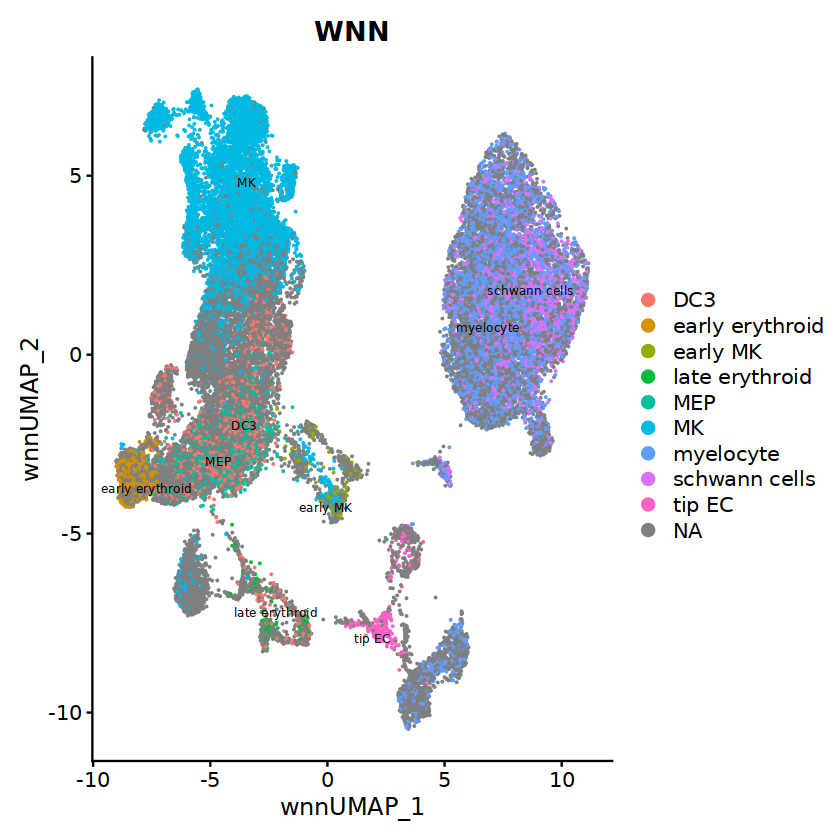

In [279]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "CellTypist_BMA_label_filtered", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3
setwd(path_graphs)
png(file='WNN_by_CellTypist_BMA_label_filtered.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

#### Subgraph conf score CellTypist_BMA_label_filtered

In [283]:
adata_subset<-subset(adata, CellTypist_BMA_label_filtered !="NA")

Warning message:
"Removing 17920 cells missing data for vars requested"


png 
  2

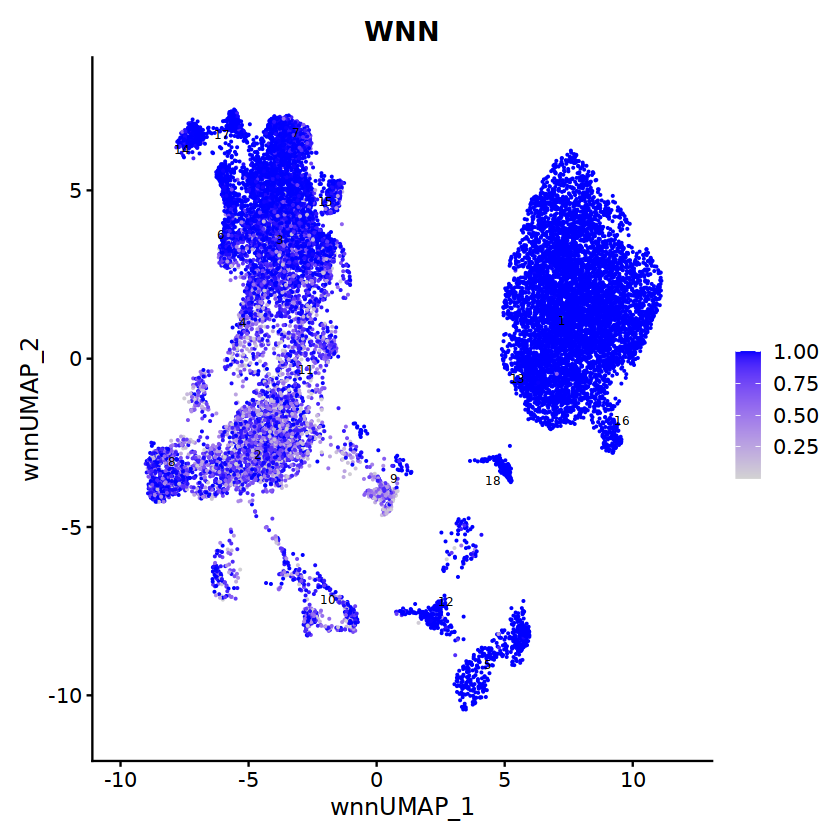

In [287]:
## Graph WNN by CellTypist_conf_score

p3 <- FeaturePlot(adata_subset, reduction = "umap.wnn", 
              features = "CellTypist_BMA_conf_score", 
              label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")

p3 & theme(plot.title = element_text(hjust = 0.5))

setwd(path_graphs)
png(file='WNN_by_CellTypist_BMA_conf_score_filtered.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

### CellTypist_IPSCs_label_filtered

png 
  2

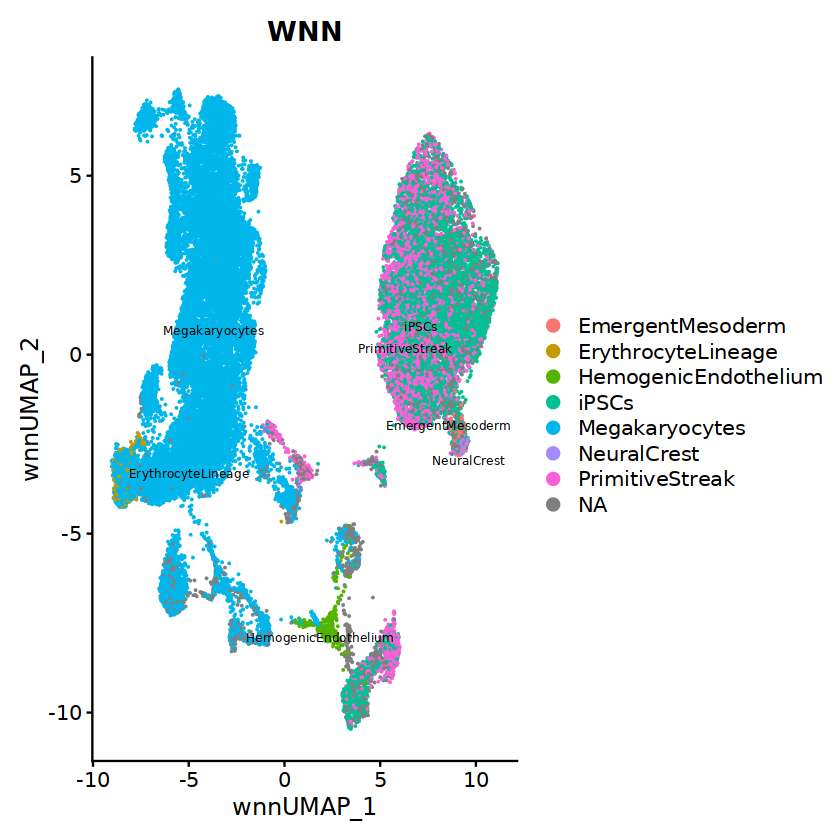

In [288]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "CellTypist_IPSCs_label_filtered", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3
setwd(path_graphs)
png(file='WNN_by_CellTypist_IPSCs_label_filtered.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

#### Subgraph conf score CellTypist_IPSCs_label_filtered

In [289]:
adata_subset<-subset(adata, CellTypist_IPSCs_label_filtered !="NA")

Warning message:
"Removing 3090 cells missing data for vars requested"


png 
  2

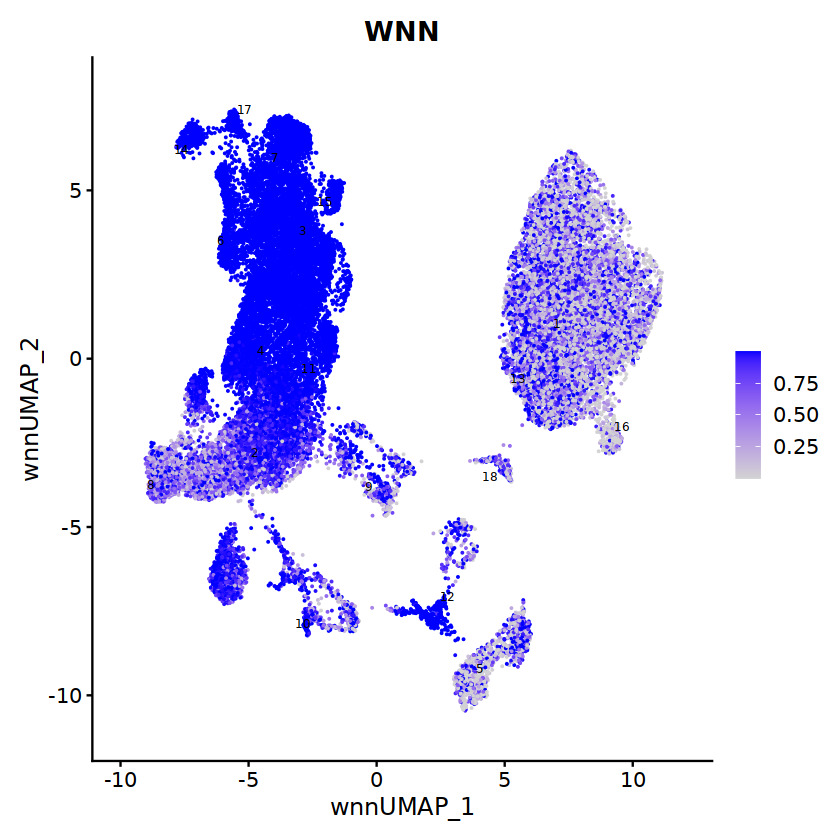

In [291]:
## Graph WNN by CellTypist_conf_score

p3 <- FeaturePlot(adata_subset, reduction = "umap.wnn", 
              features = "CellTypist_IPSCs_conf_score", 
              label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")

p3 & theme(plot.title = element_text(hjust = 0.5))

setwd(path_graphs)
png(file='WNN_by_CellTypist_IPSCs_conf_score_filtered.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

## Violin plots

### Add other ATAC measures

In [302]:
adata

An object of class Seurat 
445320 features across 37504 samples within 4 assays 
Active assay: SCT (31512 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: RNA, RNA_raw, ATAC
 7 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, umap.wnn, harmony.rna, harmony.atac

In [300]:
colnames(adata@meta.data)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "wsnn_res.0.25"                     "CellTypist_BMA_label"             
[67] "CellTypist_BMA_conf_score"         "CellTypist_IPSCs_label"           
[69] "CellTypist_IPSCs_conf_score"       "CellTypist_BMA_label_filtered"    
[71] "CellTypist_IPSCs_label_filtered"   "time_point"                       
[73] "time"

#### Nucleosome signal

In [303]:
DefaultAssay(adata)<-'ATAC'
adata <- NucleosomeSignal(object = adata)


#### FRiP

In [325]:
adata$atac_pct_reads_in_peaks <- adata$atac_peak_region_fragments / adata$atac_fragments * 100

# https://github.com/stuart-lab/signac/discussions/1049


#### QC graphs

Saving 6.67 x 6.67 in image


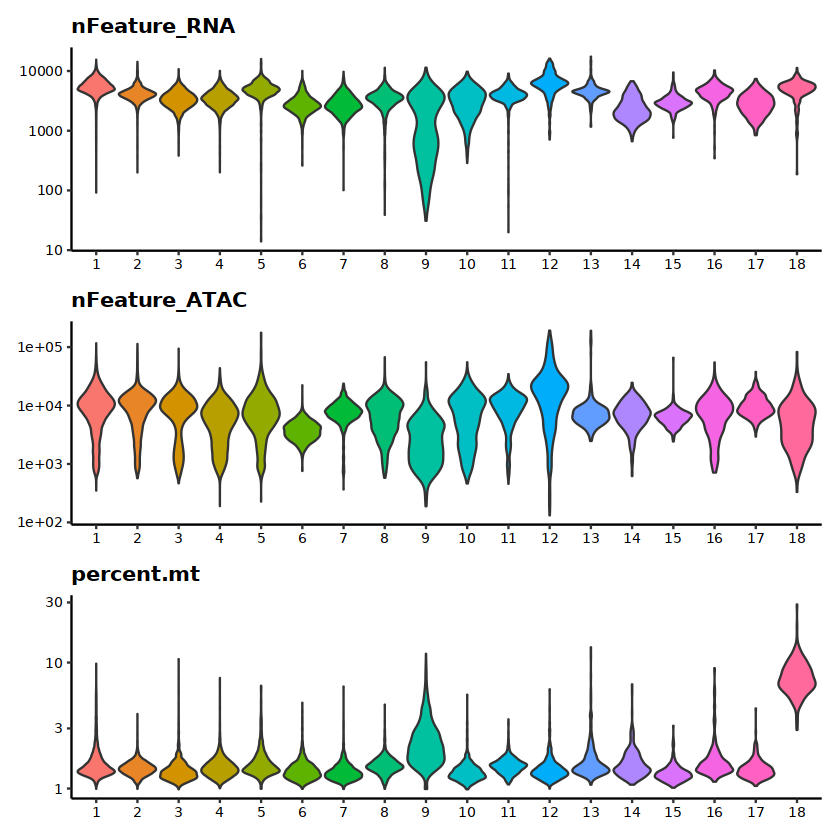

In [348]:
Vln_file_1<-VlnPlot(adata, features = c("nFeature_RNA", "nFeature_ATAC", "percent.mt"),  
          ncol = 3,
          log = TRUE, pt.size = 0)+ NoLegend()


List_Vln<-lapply(Vln_file_1 %>% seq, function(i) { Vln_file_1[[i]] & theme_classic()+
        theme(plot.title=element_text(color="black",face="bold", family="sans", size=12),
              axis.title.y=element_blank(),
              axis.title.x=element_blank(),
              axis.text.y=element_text(color="black", family="sans", size=8),
              axis.text.x=element_text(angle=0,color="black", family="sans", size=8)) +      
        theme(legend.title = element_blank(),
                      legend.text = element_text(color="black", family="sans"),
                      legend.key.size = unit(0.25, 'cm'), #change legend key size
                      legend.key.height = unit(0.25, 'cm'), #change legend key height
                      legend.key.width = unit(0.25, 'cm'), #change legend key width
                      legend.position="hidden")                                 
                                       })





setwd(path_graphs)

svgname<-paste("Vln_QC1",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= List_Vln[[1]] / List_Vln[[2]] / List_Vln[[3]],
         device="png")
}

List_Vln[[1]] / List_Vln[[2]] / List_Vln[[3]]

Saving 6.67 x 6.67 in image


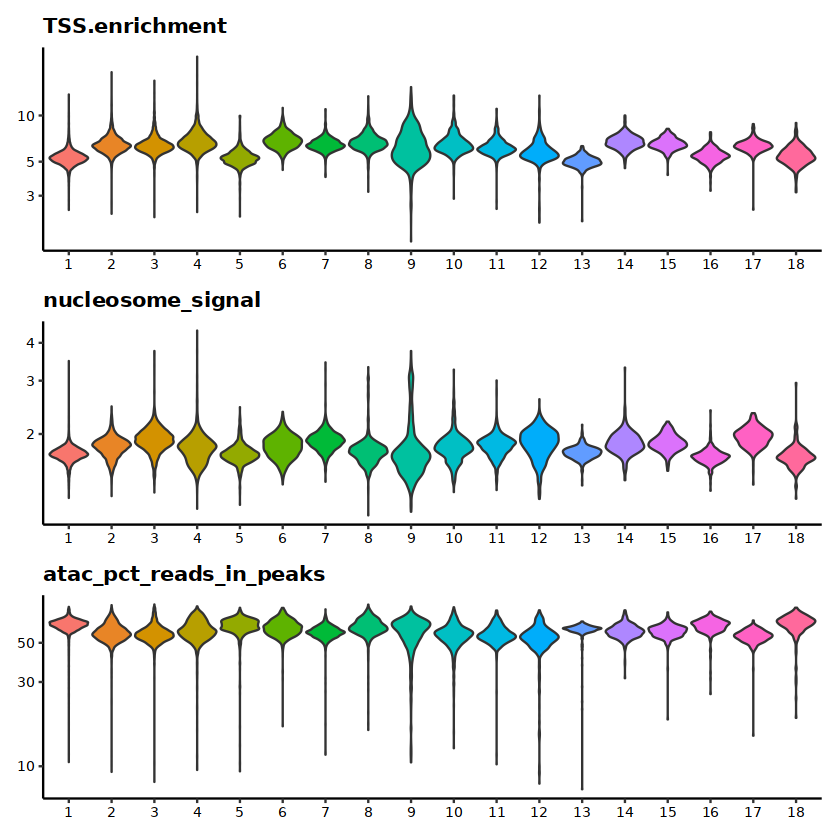

In [349]:
Vln_file_1<-VlnPlot(adata, features = c("TSS.enrichment", "nucleosome_signal", "atac_pct_reads_in_peaks"),  
          ncol = 3,
          log = TRUE, pt.size = 0)+ NoLegend()


List_Vln<-lapply(Vln_file_1 %>% seq, function(i) { Vln_file_1[[i]] & theme_classic()+
        theme(plot.title=element_text(color="black",face="bold", family="sans", size=12),
              axis.title.y=element_blank(),
              axis.title.x=element_blank(),
              axis.text.y=element_text(color="black", family="sans", size=8),
              axis.text.x=element_text(angle=0,color="black", family="sans", size=8)) +      
        theme(legend.title = element_blank(),
                      legend.text = element_text(color="black", family="sans"),
                      legend.key.size = unit(0.25, 'cm'), #change legend key size
                      legend.key.height = unit(0.25, 'cm'), #change legend key height
                      legend.key.width = unit(0.25, 'cm'), #change legend key width
                      legend.position="hidden")                                 
                                       })





setwd(path_graphs)

svgname<-paste("Vln_QC2",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= List_Vln[[1]] / List_Vln[[2]] / List_Vln[[3]],
         device="png")
}

List_Vln[[1]] / List_Vln[[2]] / List_Vln[[3]]

## DotPlots

### clusters

Saving 6.67 x 6.67 in image


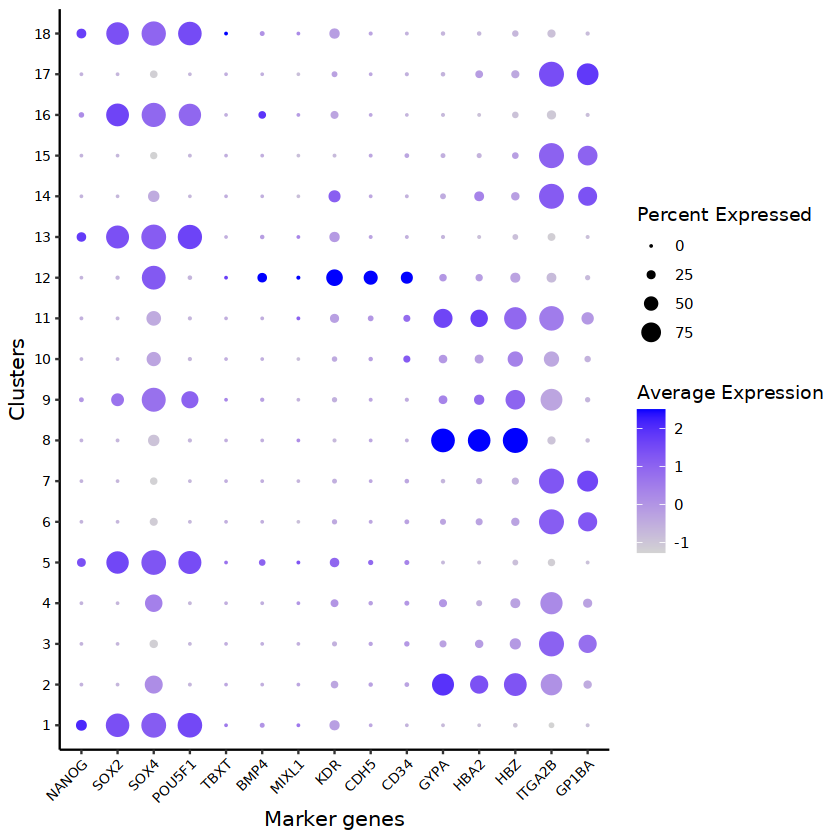

In [354]:
dotplot3<-DotPlot(
  adata,
  features=c("NANOG",'SOX2','SOX4','POU5F1',"TBXT",'BMP4','MIXL1',"KDR",'CDH5','CD34','GYPA','HBA2','HBZ','ITGA2B','GP1BA'),
  assay = "SCT",
    group.by="seurat_clusters")+
ylab('Clusters')+
xlab('Marker genes')+
 theme_classic()+
    theme(axis.title=element_blank(),
          axis.title.y=element_text(color="black", family="sans", size=12),
          axis.title.x=element_text(color="black", family="sans", size=12),
          axis.text.y=element_text(color="black", family="sans", size=8),
          axis.text.x=element_text(angle=45,vjust=1,hjust=1, color="black", family="sans", size=8))

setwd(path_graphs)

svgname<-paste("Dotplot_marker_genes_by_seurat_clusters",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= dotplot3,
         device="png")
}

dotplot3



### Cell Typist BMA

In [360]:
adata_sub<-subset(adata, CellTypist_BMA_label_filtered != "NA")

Warning message:
"Removing 17920 cells missing data for vars requested"


In [364]:
TEST<-factor(adata_sub@meta.data$CellTypist_BMA_label_filtered,
                                                         levels=c('schwann cells','myelocyte','DC3','tip EC','MK',
                                                                  'early erythroid','late erythroid', 'early MK','MK'),
                                                         ordered=T)

#adata_sub@meta.data$CellTypist_BMA_label_filtered

summary(as.factor(adata_sub@meta.data$CellTypist_BMA_label_filtered))
summary(TEST)

adata_sub$TEST<-TEST


DC3 early erythroid        early MK  late erythroid             MEP 
           1864             730             190             176            1251 
             MK       myelocyte   schwann cells          tip EC 
           7800            5019            2225             329

schwann cells       myelocyte             DC3          tip EC             MEP 
           2225            5019            1864             329            1251 
early erythroid  late erythroid        early MK              MK 
            730             176             190            7800

Saving 6.67 x 6.67 in image


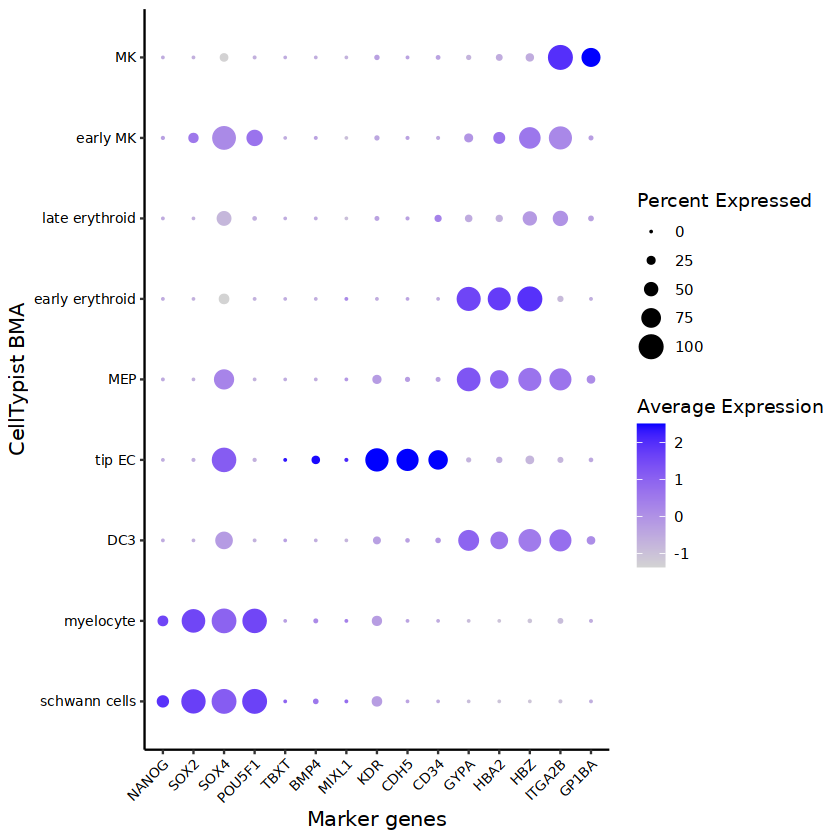

In [365]:
dotplot3<-DotPlot(
  adata_sub,
  features=c("NANOG",'SOX2','SOX4','POU5F1',"TBXT",'BMP4','MIXL1',"KDR",'CDH5','CD34','GYPA','HBA2','HBZ','ITGA2B','GP1BA'),
  assay = "SCT",
    group.by="TEST")+
ylab('CellTypist BMA')+
xlab('Marker genes')+
 theme_classic()+
    theme(axis.title=element_blank(),
          axis.title.y=element_text(color="black", family="sans", size=12),
          axis.title.x=element_text(color="black", family="sans", size=12),
          axis.text.y=element_text(color="black", family="sans", size=8),
          axis.text.x=element_text(angle=45,vjust=1,hjust=1, color="black", family="sans", size=8))

setwd(path_graphs)

svgname<-paste("Dotplot_marker_genes_by_CellTypist_BMA_label_filtered",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= dotplot3,
         device="png")
}

dotplot3

### Cell Typist IPSCs

In [366]:
adata_sub<-subset(adata, CellTypist_IPSCs_label_filtered != "NA")

Warning message:
"Removing 3090 cells missing data for vars requested"


In [371]:
TEST<-factor(adata_sub@meta.data$CellTypist_IPSCs_label_filtered,
                                                         levels=c('iPSCs','PrimitiveStreak','EmergentMesoderm','NeuralCrest',
                                                                  'HemogenicEndothelium','ErythrocyteLineage','Megakaryocytes'),
                                                         ordered=T)


summary(as.factor(adata_sub@meta.data$CellTypist_IPSCs_label_filtered))
summary(TEST)

adata_sub$TEST<-TEST


EmergentMesoderm   ErythrocyteLineage HemogenicEndothelium 
                  83                  270                  361 
               iPSCs       Megakaryocytes          NeuralCrest 
                6801                22077                   80 
     PrimitiveStreak 
                4742

iPSCs      PrimitiveStreak     EmergentMesoderm 
                6801                 4742                   83 
         NeuralCrest HemogenicEndothelium   ErythrocyteLineage 
                  80                  361                  270 
      Megakaryocytes 
               22077

Saving 6.67 x 6.67 in image


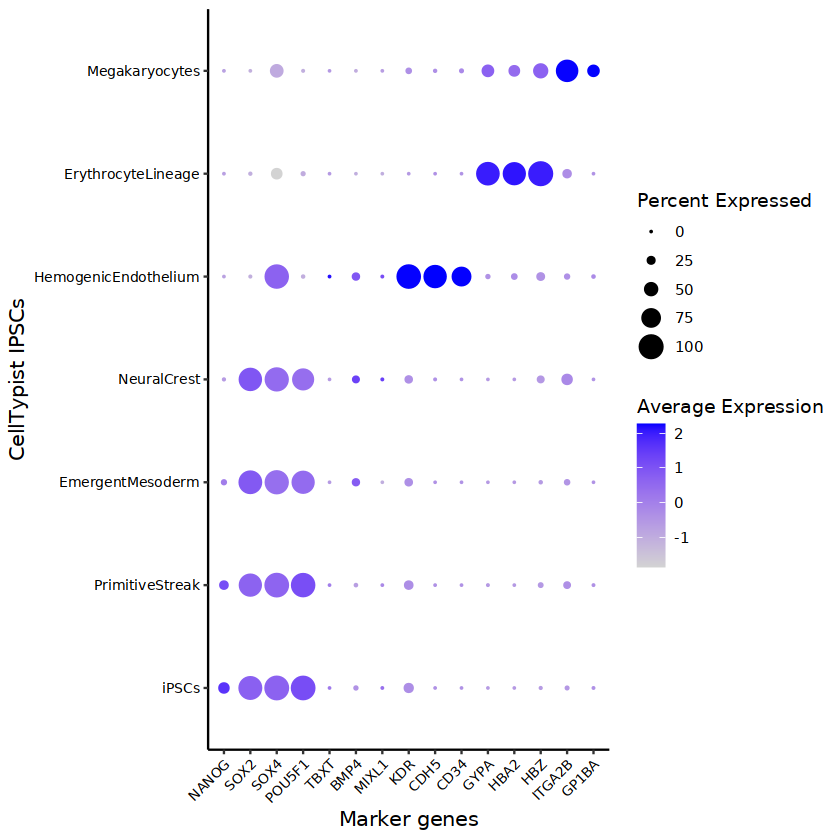

In [372]:
dotplot3<-DotPlot(
  adata_sub,
  features=c("NANOG",'SOX2','SOX4','POU5F1',"TBXT",'BMP4','MIXL1',"KDR",'CDH5','CD34','GYPA','HBA2','HBZ','ITGA2B','GP1BA'),
  assay = "SCT",
    group.by="TEST")+
ylab('CellTypist IPSCs')+
xlab('Marker genes')+
 theme_classic()+
    theme(axis.title=element_blank(),
          axis.title.y=element_text(color="black", family="sans", size=12),
          axis.title.x=element_text(color="black", family="sans", size=12),
          axis.text.y=element_text(color="black", family="sans", size=8),
          axis.text.x=element_text(angle=45,vjust=1,hjust=1, color="black", family="sans", size=8))

setwd(path_graphs)

svgname<-paste("Dotplot_marker_genes_by_CellTypist_IPSCs_label_filtered",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= dotplot3,
         device="png")
}

dotplot3

# My annotation

In [385]:
adata@meta.data$my_anot<-'No cell type assigned'

In [386]:
adata@meta.data$my_anot[which(adata@meta.data$CellTypist_IPSCs_label_filtered%in%c('iPSCs','PrimitiveStreak','EmergentMesoderm','NeuralCrest'))]<-'hESCs'

In [387]:
adata@meta.data$my_anot[which(adata@meta.data$CellTypist_IPSCs_label_filtered%in%c('HemogenicEndothelium'))]<-'HSCs'

In [388]:
indx_BMA<-which(adata@meta.data$CellTypist_BMA_label_filtered%in%c('MEP','early erythroid','late erythroid','early MK','MK'))

In [389]:
adata@meta.data$my_anot[indx_BMA]<-adata@meta.data$CellTypist_BMA_label_filtered[indx_BMA]

In [390]:
summary(as.factor(adata@meta.data$my_anot))

early erythroid              early MK                 hESCs 
                  730                   190                 11681 
                 HSCs        late erythroid                   MEP 
                  361                   176                  1251 
                   MK No cell type assigned 
                 7800                 15315

In [392]:
adata@meta.data$my_anot<-factor(adata@meta.data$my_anot,
                               levels=c('hESCs','HSCs','MEP','early erythroid','late erythroid','early MK','MK','No cell type assigned'),
                               ordered=T)

In [393]:
summary(adata@meta.data$my_anot)

hESCs                  HSCs                   MEP 
                11681                   361                  1251 
      early erythroid        late erythroid              early MK 
                  730                   176                   190 
                   MK No cell type assigned 
                 7800                 15315

# New graphs after my annotation

## Stacked barplots

### my anot vs seurat clusters

In [400]:
met<-adata[[]]

In [401]:
met.dt<-data.table(met,key=c("seurat_clusters","my_anot"))

In [402]:
#str(met.dt)

In [404]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [405]:
met.dt<-data.table(met, key=c("seurat_clusters"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [406]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by="seurat_clusters")
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [407]:
str(Freq.table)

'data.frame':	37 obs. of  5 variables:
 $ seurat_clusters: Factor w/ 18 levels "1","2","3","4",..: 1 1 10 10 11 12 12 13 13 14 ...
 $ my_anot        : Ord.factor w/ 8 levels "hESCs"<"HSCs"<..: 1 8 5 8 8 2 8 1 8 7 ...
 $ Freq           : int  9488 1283 176 870 983 361 463 413 39 402 ...
 $ TOTAL          : int  10771 10771 1046 1046 983 824 824 452 452 419 ...
 $ Perc           : num  88.1 11.9 16.8 83.2 100 ...


In [408]:
met.dt<-data.table(met, key=c("my_anot"))
Freq.table_BMA<-as.data.frame(met.dt[,.(Freq_my_anot=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.table_BMA,
                  by="my_anot")

#Freq.table

In [409]:
str(Freq.table)

'data.frame':	37 obs. of  6 variables:
 $ my_anot        : Ord.factor w/ 8 levels "hESCs"<"HSCs"<..: 4 6 1 1 1 1 1 1 2 5 ...
 $ seurat_clusters: Factor w/ 18 levels "1","2","3","4",..: 8 9 1 16 13 18 5 9 12 10 ...
 $ Freq           : int  730 190 9488 246 413 209 1122 203 361 176 ...
 $ TOTAL          : int  1334 1103 10771 372 452 248 1474 1103 824 1046 ...
 $ Perc           : num  54.7 17.2 88.1 66.1 91.4 ...
 $ Freq_my_anot   : int  730 190 11681 11681 11681 11681 11681 11681 361 176 ...


In [423]:
vector_colors_my_anot<-c(brewer.pal(7, "Set1"),"gray")

In [424]:
library(forcats)


-------------------------------------->	0 25 50 75 100


Saving 6.67 x 6.67 in image


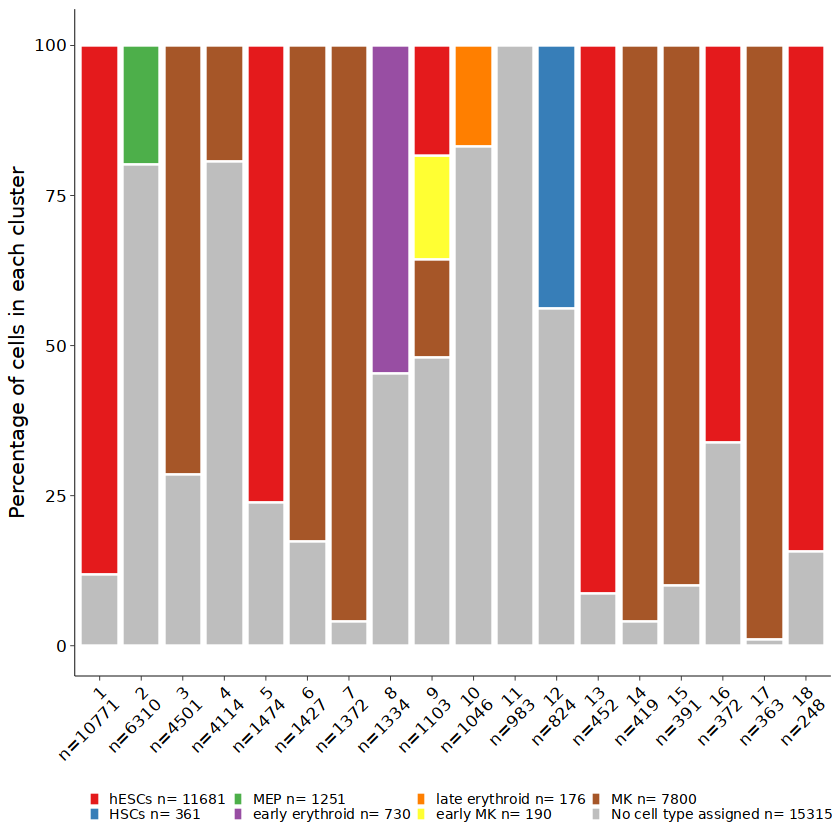

In [432]:
 #### Stacked Graph ---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-Freq.table %>%
    mutate(myaxis = paste0(seurat_clusters, "\n", "n=", TOTAL), drop=F) %>%
    mutate(myaxis=fct_reorder(myaxis,as.numeric(seurat_clusters)), drop=F) %>%
    ggplot(aes(x=myaxis, y=Perc, fill=my_anot)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cluster",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_my_anot,
                      drop=F,
                      name="My Annotation", breaks=Freq.table_BMA$my_anot,
                      labels=paste(Freq.table_BMA$my_anot,
                                   Freq.table_BMA$Freq_my_anot, sep =' n= '))+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=10,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=8, color="black", family="sans"),
                  legend.key.size = unit(0.25, 'cm'), #change legend key size
                  legend.key.height = unit(0.25, 'cm'), #change legend key height
                  legend.key.width = unit(0.25, 'cm'), #change legend key width
                  legend.position="bottom")
  
  

setwd(path_graphs)

svgname<-paste("stacked_barplot_seurat_clusters_vs_my_anot",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="png")
}

stacked_barplot
  

### my anot vs seurat clusters vs time_point

In [433]:
met<-adata[[]]

In [434]:
met.dt<-data.table(met,key=c("time_point","seurat_clusters","my_anot"))

In [435]:
#str(met.dt)

In [436]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [437]:
met.dt<-data.table(met, key=c("time_point","seurat_clusters"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [438]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("time_point","seurat_clusters"))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [439]:
str(Freq.table)

'data.frame':	98 obs. of  6 variables:
 $ time_point     : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ seurat_clusters: Factor w/ 18 levels "1","2","3","4",..: 1 1 13 13 16 16 18 18 5 5 ...
 $ my_anot        : Ord.factor w/ 8 levels "hESCs"<"HSCs"<..: 1 8 1 8 1 8 1 8 1 8 ...
 $ Freq           : int  9488 1269 413 31 245 115 209 23 1121 226 ...
 $ TOTAL          : int  10757 10757 444 444 360 360 232 232 1347 1347 ...
 $ Perc           : num  88.2 11.8 93.02 6.98 68.06 ...


In [440]:
met.dt<-data.table(met, key=c("time_point"))
Freq.time_point<-as.data.frame(met.dt[,.(ntime=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.time_point,
                  by="time_point")

#Freq.table

In [441]:
str(Freq.table)

'data.frame':	98 obs. of  7 variables:
 $ time_point     : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ seurat_clusters: Factor w/ 18 levels "1","2","3","4",..: 1 1 13 13 16 16 18 18 5 5 ...
 $ my_anot        : Ord.factor w/ 8 levels "hESCs"<"HSCs"<..: 1 8 1 8 1 8 1 8 1 8 ...
 $ Freq           : int  9488 1269 413 31 245 115 209 23 1121 226 ...
 $ TOTAL          : int  10757 10757 444 444 360 360 232 232 1347 1347 ...
 $ Perc           : num  88.2 11.8 93.02 6.98 68.06 ...
 $ ntime          : int  13520 13520 13520 13520 13520 13520 13520 13520 13520 13520 ...


In [462]:
Freq.TOTAL<-merge(Freq.TOTAL,
                  Freq.time_point,
                  by="time_point")

In [442]:
vector_colors_my_anot<-c(brewer.pal(7, "Set1"),"gray")

In [445]:
library(forcats)
library(cowplot)


Attaching package: 'cowplot'


The following object is masked from 'package:patchwork':

    align_plots


The following object is masked from 'package:ggpubr':

    get_legend




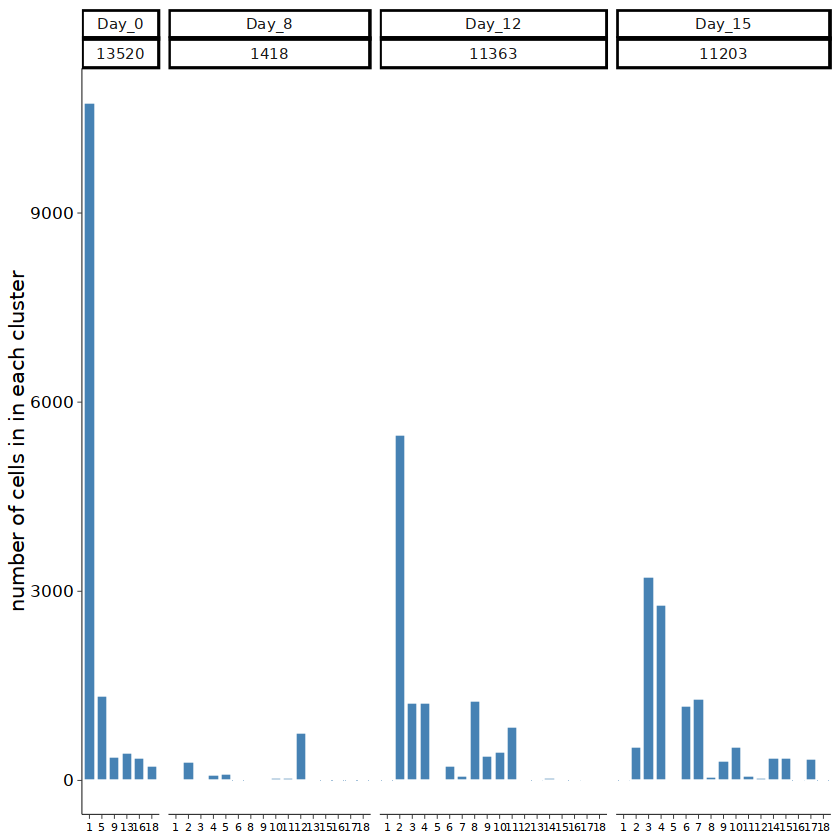

In [467]:
#### Stacked Graph #1 ---------------
  
  
  
  
  stacked_barplot<-ggplot(data=Freq.TOTAL,
                          aes(x=seurat_clusters, y=TOTAL)) +
    geom_bar(stat = "identity",
             colour='white', fill="steelblue")+
    scale_y_continuous(name=paste("number of cells in in each cluster",sep=" "))


stacked_barplot<-stacked_barplot+
  theme_cowplot(font_size = 2)+
  facet_grid(. ~ time_point+ntime, scales='free_x', space='free_x', switch="y", labeller=labeller(paste0(Freq.table$time_point, "\n", "n=", Freq.table$ntime)))+   
  scale_x_discrete(name="Seurat clusters", drop=T)+
  theme( strip.background = element_blank(),
         strip.placement = "outside",
         strip.text = element_text(size=6),
         panel.spacing = unit(0.2, "lines"),
         panel.background=element_rect(fill="white"),
         panel.border=element_rect(colour="white",size=0,5),
         panel.grid.major = element_blank(),
         panel.grid.minor = element_blank())+
  theme_classic()+
  theme(axis.title.y=element_text(size=12, color="black", family="sans"),
        axis.title.x=element_blank(),
        axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
        axis.text.x=element_text(angle=0,size=6,color="black", family="sans"),
        axis.line.x = element_line(size = 0.2),
        axis.ticks.x = element_line(size = 0.2),
        axis.ticks.y = element_line(size = 0.2),
        axis.line.y = element_line(size = 0.2))+
  theme(legend.title = element_blank(),
        legend.text = element_text(size=8, color="black", family="sans"),
        legend.key.size = unit(0.25, 'cm'), #change legend key size
        legend.key.height = unit(0.25, 'cm'), #change legend key height
        legend.key.width = unit(0.25, 'cm'), #change legend key width
        legend.position="bottom")

setwd(path_graphs)

svgname<-paste("stacked_barplot_time_point_seurat_clusters_vs_my_anot_part_1",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="png",
        width=12, height=3)
}
    
stacked_barplot

-------------------------------------->	0 25 50 75 100


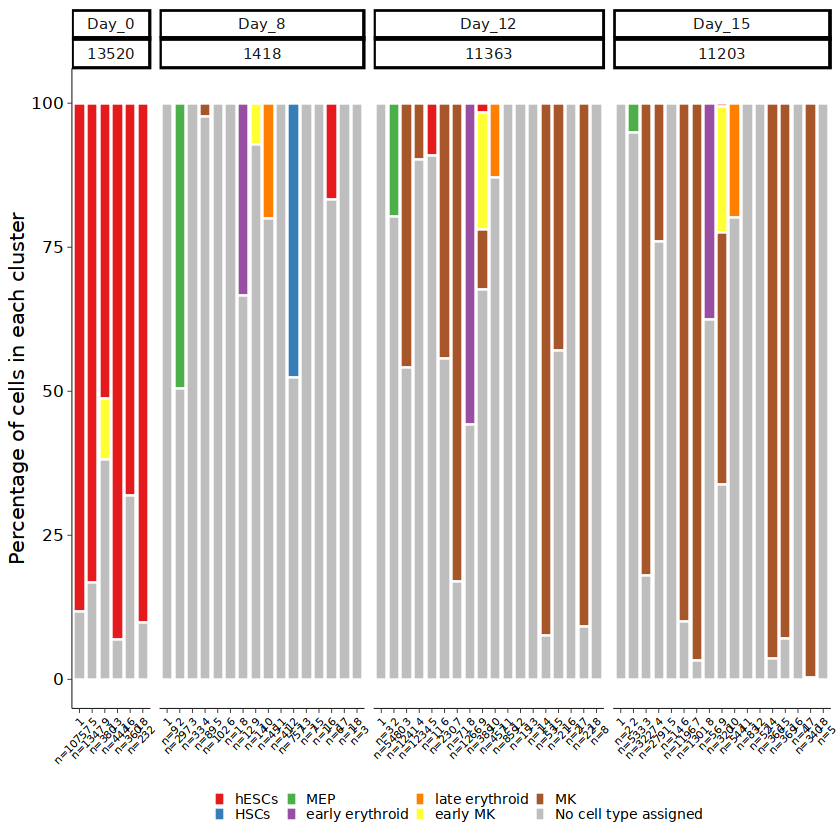

In [449]:
#### Stacked Graph #2---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-Freq.table %>%
    mutate(myaxis = paste0(seurat_clusters, "\n", "n=", TOTAL), drop=F) %>%
    mutate(myaxis=fct_reorder(myaxis,as.numeric(seurat_clusters)), drop=F) %>%
    ggplot(aes(x=myaxis, y=Perc, fill=my_anot)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cluster",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_my_anot,
                      drop=F,
                      name="My Annotation")

 stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ time_point+ntime, scales='free_x', space='free_x', switch="y", labeller=labeller(paste0(Freq.table$time_point, "\n", "n=", Freq.table$ntime)))+   
    scale_x_discrete(name="Seurat clusters", drop=T)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=6),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=6,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=8, color="black", family="sans"),
                  legend.key.size = unit(0.25, 'cm'), #change legend key size
                  legend.key.height = unit(0.25, 'cm'), #change legend key height
                  legend.key.width = unit(0.25, 'cm'), #change legend key width
                  legend.position="bottom")

setwd(path_graphs)

svgname<-paste("stacked_barplot_time_point_seurat_clusters_vs_my_anot",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="png",
        width=12, height=6)
}

stacked_barplot

# SAVE

In [468]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

saveRDS(adata,file="merged_processed_presentation.rds")

# Read checkpoint #1

In [196]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

adata<-readRDS(file="merged_processed_presentation.rds")

In [197]:
adata

An object of class Seurat 
445320 features across 37504 samples within 4 assays 
Active assay: ATAC (340606 features, 340606 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, umap.wnn, harmony.rna, harmony.atac

In [198]:
colnames(adata@meta.data)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "wsnn_res.0.25"                     "CellTypist_BMA_label"             
[67] "CellTypist_BMA_conf_score"         "CellTypist_IPSCs_label"           
[69] "CellTypist_IPSCs_conf_score"       "CellTypist_BMA_label_filtered"    
[71] "CellTypist_IPSCs_label_filtered"   "time_point"                       
[73] "time"                              "nucleosome_signal"                
[75] "nucleosome_percentile"             "FRiP"                             
[77] "atac_pct_reads_in_peaks"           "my_anot"

# Find marker genes for Cluster 2 unassigned cells

In [199]:
library(presto)

## Define which subsets of cells from cluster 2 I am interested in comparing

In [200]:
met<-adata[[]]

In [201]:
met_2<-met[which(met$seurat_clusters == '2'),]

In [202]:
summary(droplevels(met_2$my_anot))

MEP No cell type assigned 
                 1251                  5059

In [203]:
met_2_MEP_CellIDs<-row.names(met_2)[which(met_2$my_anot == 'MEP')]

str(met_2_MEP_CellIDs)

 chr [1:1251] "MCO_01327_AAACCGGCAGCAAGTG-1" "MCO_01327_AAAGCACCAAAGCCTC-1" ...


In [204]:
met_2_unassigned_CellIDs<-row.names(met_2)[which(met_2$my_anot == 'No cell type assigned')]

str(met_2_unassigned_CellIDs)

 chr [1:5059] "MCO_01327_AAATGCCTCCCAGTAG-1" "MCO_01327_AAATGCCTCCTCCATA-1" ...


## Add these columns to the metadata

In [205]:
adata@meta.data$FOI<-NA

In [206]:
adata@meta.data$FOI[which(row.names(adata@meta.data)%in%met_2_unassigned_CellIDs)]<-'Cluster 2 No cell type assigned'

In [207]:
adata@meta.data$FOI[which(row.names(adata@meta.data)%in%met_2_MEP_CellIDs)]<-'Cluster 2 MEP'

In [208]:
adata@meta.data$FOI<-factor(adata@meta.data$FOI, levels=c('Cluster 2 MEP','Cluster 2 No cell type assigned'))

In [209]:
summary(adata@meta.data$FOI)

Cluster 2 MEP Cluster 2 No cell type assigned 
                           1251                            5059 
                           NA's 
                          31194

In [210]:
adata_sub<-subset(adata, FOI != "NA")

Warning message:
"Removing 31194 cells missing data for vars requested"


## Find marker genes function

In [211]:
DefaultAssay(adata)<-'SCT'
cluster_2_intra<-FindMarkers(adata, ident.1=met_2_MEP_CellIDs,ident.2=met_2_unassigned_CellIDs, logfc.threshold = 0.2, min.pct = 0.25)

In [212]:
str(cluster_2_intra)
str(row.names(cluster_2_intra))


'data.frame':	3070 obs. of  5 variables:
 $ p_val     : num  1.25e-87 9.76e-60 3.49e-54 4.74e-54 3.59e-51 ...
 $ avg_log2FC: num  1.263 0.336 0.333 0.628 0.341 ...
 $ pct.1     : num  0.47 1 1 0.95 1 0.994 0.983 0.975 1 0.973 ...
 $ pct.2     : num  0.197 1 1 0.871 1 0.984 0.94 0.92 0.999 0.937 ...
 $ p_val_adj : num  3.95e-83 3.08e-55 1.10e-49 1.49e-49 1.13e-46 ...
 chr [1:3070] "CLDN10" "PTMA" "EEF1A1" "TMSB10" "HMGB1" "SET" "DDX21" "SSB" ...


In [213]:
cluster_2_intra_SIG<-cluster_2_intra[which(cluster_2_intra$p_val_adj < 0.001),]
cluster_2_intra_SIG$gene<-row.names(cluster_2_intra_SIG)

cluster_2_intra_SIG<-cluster_2_intra_SIG[order(cluster_2_intra_SIG$avg_log2FC, decreasing=F),]

In [214]:
str(cluster_2_intra_SIG)

'data.frame':	1490 obs. of  6 variables:
 $ p_val     : num  1.38e-29 1.47e-31 1.80e-25 3.52e-28 3.58e-37 ...
 $ avg_log2FC: num  -2.4 -2.17 -2.17 -2.14 -2.09 ...
 $ pct.1     : num  0.133 0.214 0.206 0.13 0.304 0.184 0.213 0.197 0.15 0.186 ...
 $ pct.2     : num  0.277 0.369 0.343 0.268 0.477 0.323 0.359 0.327 0.265 0.29 ...
 $ p_val_adj : num  4.34e-25 4.62e-27 5.66e-21 1.11e-23 1.13e-32 ...
 $ gene      : chr  "DNM3" "THBS1" "PF4" "SLC37A1" ...


In [215]:
cluster_2_intra_SIG_UP<-cluster_2_intra_SIG[which(cluster_2_intra_SIG$avg_log2FC < 0),]
str(cluster_2_intra_SIG_UP)

'data.frame':	54 obs. of  6 variables:
 $ p_val     : num  1.38e-29 1.47e-31 1.80e-25 3.52e-28 3.58e-37 ...
 $ avg_log2FC: num  -2.4 -2.17 -2.17 -2.14 -2.09 ...
 $ pct.1     : num  0.133 0.214 0.206 0.13 0.304 0.184 0.213 0.197 0.15 0.186 ...
 $ pct.2     : num  0.277 0.369 0.343 0.268 0.477 0.323 0.359 0.327 0.265 0.29 ...
 $ p_val_adj : num  4.34e-25 4.62e-27 5.66e-21 1.11e-23 1.13e-32 ...
 $ gene      : chr  "DNM3" "THBS1" "PF4" "SLC37A1" ...


In [216]:
cluster_2_intra_SIG_UP$gene

[1] "DNM3"     "THBS1"    "PF4"      "SLC37A1"  "LTBP1"    "PLEK"    
 [7] "RAB27B"   "PDE5A"    "COL24A1"  "ZC3H12C"  "PDE3A"    "PCSK6"   
[13] "INPP4B"   "BIN2"     "MYO18B"   "TBXAS1"   "DOK6"     "TUBB1"   
[19] "MYLK"     "ATP8A1"   "ITGB3"    "CPEB2"    "MEIS1"    "MAST4"   
[25] "PRKCA"    "TJP2"     "NLK"      "SPTB"     "MCTP1"    "FYB1"    
[31] "STARD13"  "CNST"     "MFAP3L"   "ARHGAP6"  "ARHGAP18" "TRPC6"   
[37] "RGS6"     "KCNT2"    "VCL"      "NEAT1"    "TEC"      "TSPAN32" 
[43] "LRP12"    "DAAM1"    "PROS1"    "LIMS1"    "MALAT1"   "GTDC1"   
[49] "RABGAP1L" "DIAPH3"   "ITFG1"    "PHKB"     "UTY"      "NBAS"

In [217]:
cluster_2_intra_SIG_DOWN<-cluster_2_intra_SIG[which(cluster_2_intra_SIG$avg_log2FC > 0),]
str(cluster_2_intra_SIG_DOWN)

'data.frame':	1436 obs. of  6 variables:
 $ p_val     : num  1.23e-14 7.52e-12 1.90e-10 3.36e-10 2.16e-11 ...
 $ avg_log2FC: num  0.2 0.201 0.202 0.202 0.202 ...
 $ pct.1     : num  0.972 0.953 0.89 0.89 0.967 0.883 0.973 0.957 0.979 0.889 ...
 $ pct.2     : num  0.943 0.882 0.839 0.837 0.958 0.84 0.938 0.938 0.96 0.84 ...
 $ p_val_adj : num  3.89e-10 2.37e-07 5.99e-06 1.06e-05 6.81e-07 ...
 $ gene      : chr  "LRPPRC" "ELOVL6" "NAA15" "PSMA1" ...


In [218]:
row_max<-as.integer(dim(cluster_2_intra_SIG_DOWN)[1])
row_max

[1] 1436

In [219]:
cluster_2_intra_SIG_DOWN$gene[c((row_max -row_max+1) : (row_max -1350))]

[1] "LRPPRC"   "ELOVL6"   "NAA15"    "PSMA1"    "SRSF2"    "FXR1"    
 [7] "VAPA"     "SERF2"    "XPO1"     "TFDP2"    "LDLRAD3"  "RPLP1"   
[13] "H3F3B"    "ARIH1"    "ATP5F1E"  "ILF3"     "PRRC2C"   "CMSS1"   
[19] "NAP1L1"   "SNHG3"    "PDZD8"    "G3BP2"    "NDUFS1"   "SLC5A3"  
[25] "GAS5"     "ACTB"     "TUBGCP5"  "MYL4"     "FDFT1"    "LIN28B"  
[31] "ZEB1"     "TXNRD1"   "HNRNPC"   "MT-CO3"   "TPR"      "PSMB7"   
[37] "METAP2"   "ADNP"     "CLNS1A"   "IQGAP1"   "FKBP5"    "CCDC88A" 
[43] "FADS2"    "RREB1"    "SSBP3"    "EWSR1"    "PRKD3"    "MTHFD2"  
[49] "MT-ATP6"  "TMEM14C"  "PUM3"     "FIRRE"    "SEPTIN11" "HNRNPR"  
[55] "RABGGTB"  "ZBTB44"   "ACSL3"    "CREB3L2"  "TBC1D4"   "CEP170"  
[61] "ANAPC5"   "TOP2B"    "HSD17B12" "NCKAP1"   "ACTR2"    "RHOA"    
[67] "CSNK2A1"  "RBBP4"    "DHX36"    "FADS1"    "MT-ND5"   "LAPTM5"  
[73] "BZW2"     "DEK"      "RBM3"     "LARS"     "HNRNPH1"  "TFG"     
[79] "SRSF1"    "MDN1"     "HK1"      "MOB1A"    "DUT"      "TMOD3"   
[85] "DAPK1"    "MRPS35"

## Dotplot

In [220]:
path_graphs<-"/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/graphs_FINAL_presentation"

Warning message:
"Scaling data with a low number of groups may produce misleading results"
Saving 6.67 x 6.67 in image


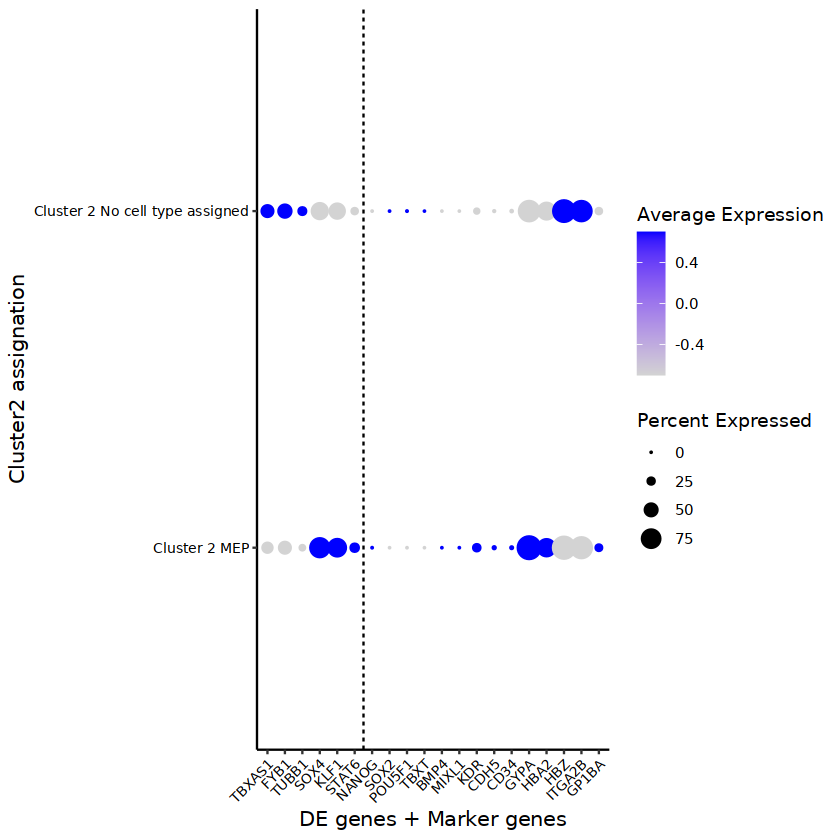

In [221]:
dotplot3<-DotPlot(
  adata_sub,
  features=c("TBXAS1","FYB1","TUBB1",'SOX4','KLF1','STAT6',
             "NANOG",'SOX2','POU5F1',"TBXT",'BMP4','MIXL1',"KDR",'CDH5','CD34','GYPA','HBA2','HBZ','ITGA2B','GP1BA'),
  assay = "SCT",
    group.by="FOI")+
ylab('Cluster2 assignation')+
xlab('DE genes + Marker genes')+
geom_vline(xintercept=6.5, linetype='dashed')+
 theme_classic()+
    theme(axis.title=element_blank(),
          axis.title.y=element_text(color="black", family="sans", size=12),
          axis.title.x=element_text(color="black", family="sans", size=12),
          axis.text.y=element_text(color="black", family="sans", size=8),
          axis.text.x=element_text(angle=45,vjust=1,hjust=1, color="black", family="sans", size=8))


setwd(path_graphs)

svgname<-paste("Dotplot_cluster2_exploration_DE_genes_and_marker_genes",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= dotplot3,
         device="png")
}

dotplot3

# Find marker genes for Cluster 4 unassigned cells

In [222]:
#library(presto)

## Define which subsets of cells from cluster 4 I am interested in comparing

In [223]:
met<-adata[[]]

In [224]:
met_4<-met[which(met$seurat_clusters == '4'),]

In [225]:
summary(droplevels(met_4$my_anot))

MK No cell type assigned 
                  794                  3320

In [226]:
met_4_MK_CellIDs<-row.names(met_4)[which(met_4$my_anot == 'MK')]

str(met_4_MK_CellIDs)

 chr [1:794] "MCO_01327_AGTAATGCATTGCGAC-1" "MCO_01327_CGCCTGTGTAATAGCT-1" ...


In [227]:
met_4_unassigned_CellIDs<-row.names(met_4)[which(met_4$my_anot == 'No cell type assigned')]

str(met_4_unassigned_CellIDs)

 chr [1:3320] "MCO_01327_AAAGGTTAGCCTGATG-1" "MCO_01327_AACCTCACACCACAAC-1" ...


## Add these columns to the metadata

In [228]:
adata@meta.data$FOI<-NA

In [229]:
adata@meta.data$FOI[which(row.names(adata@meta.data)%in%met_4_unassigned_CellIDs)]<-'Cluster 4 No cell type assigned'

In [230]:
adata@meta.data$FOI[which(row.names(adata@meta.data)%in%met_4_MK_CellIDs)]<-'Cluster 4 MK'

In [231]:
adata@meta.data$FOI<-factor(adata@meta.data$FOI, levels=c('Cluster 4 MK','Cluster 4 No cell type assigned'))

In [232]:
summary(adata@meta.data$FOI)

Cluster 4 MK Cluster 4 No cell type assigned 
                            794                            3320 
                           NA's 
                          33390

In [233]:
adata_sub<-subset(adata, FOI != "NA")

Warning message:
"Removing 33390 cells missing data for vars requested"


## Find marker genes function

In [234]:
DefaultAssay(adata)<-'SCT'
cluster_2_intra<-FindMarkers(adata, ident.1=met_4_MK_CellIDs,ident.2=met_4_unassigned_CellIDs, logfc.threshold = 0.2, min.pct = 0.25)

In [235]:
str(cluster_2_intra)
str(row.names(cluster_2_intra))


'data.frame':	3888 obs. of  5 variables:
 $ p_val     : num  1.93e-186 2.51e-183 2.86e-164 2.37e-156 2.57e-155 ...
 $ avg_log2FC: num  2.88 2.69 2.72 2.09 1.81 ...
 $ pct.1     : num  0.588 0.613 0.623 0.764 0.94 0.873 0.348 0.894 0.603 0.736 ...
 $ pct.2     : num  0.135 0.148 0.184 0.323 0.68 0.573 0.045 0.617 0.199 0.321 ...
 $ p_val_adj : num  6.07e-182 7.91e-179 9.03e-160 7.46e-152 8.10e-151 ...
 chr [1:3888] "TUBB1" "CLEC1B" "PCSK6" "DGKI" "THBS1" "PPBP" "DAPP1" "CNST" ...


In [236]:
cluster_2_intra_SIG<-cluster_2_intra[which(cluster_2_intra$p_val_adj < 0.001),]
cluster_2_intra_SIG$gene<-row.names(cluster_2_intra_SIG)

cluster_2_intra_SIG<-cluster_2_intra_SIG[order(cluster_2_intra_SIG$avg_log2FC, decreasing=F),]

In [237]:
str(cluster_2_intra_SIG)

'data.frame':	2033 obs. of  6 variables:
 $ p_val     : num  4.17e-26 5.88e-63 3.55e-62 1.81e-73 2.90e-28 ...
 $ avg_log2FC: num  -2.18 -2.13 -2.11 -1.97 -1.92 ...
 $ pct.1     : num  0.092 0.173 0.188 0.176 0.081 0.225 0.089 0.188 0.154 0.121 ...
 $ pct.2     : num  0.262 0.498 0.508 0.539 0.263 0.565 0.267 0.376 0.35 0.336 ...
 $ p_val_adj : num  1.31e-21 1.85e-58 1.12e-57 5.71e-69 9.13e-24 ...
 $ gene      : chr  "AUTS2" "ZNF521" "SPRED1" "FREM1" ...


In [238]:
cluster_2_intra_SIG$gene[grep("^KIF",cluster_2_intra_SIG$gene)]

[1] "KIF11"  "KIF20B" "KIF13A" "KIF1B"  "KIF13B" "KIF5B"  "KIFC3"  "KIF2A"

In [239]:
cluster_2_intra_SIG_UP<-cluster_2_intra_SIG[which(cluster_2_intra_SIG$avg_log2FC < 0),]
str(cluster_2_intra_SIG_UP)

'data.frame':	1608 obs. of  6 variables:
 $ p_val     : num  4.17e-26 5.88e-63 3.55e-62 1.81e-73 2.90e-28 ...
 $ avg_log2FC: num  -2.18 -2.13 -2.11 -1.97 -1.92 ...
 $ pct.1     : num  0.092 0.173 0.188 0.176 0.081 0.225 0.089 0.188 0.154 0.121 ...
 $ pct.2     : num  0.262 0.498 0.508 0.539 0.263 0.565 0.267 0.376 0.35 0.336 ...
 $ p_val_adj : num  1.31e-21 1.85e-58 1.12e-57 5.71e-69 9.13e-24 ...
 $ gene      : chr  "AUTS2" "ZNF521" "SPRED1" "FREM1" ...


In [240]:
row_max<-as.integer(dim(cluster_2_intra_SIG_UP)[1])
row_max

[1] 1608

In [241]:
#cluster_2_intra_SIG_UP$gene[c((row_max -row_max+1) : (row_max -1350))]

In [242]:
cluster_2_intra_SIG_UP$gene[grep("^ANAP",cluster_2_intra_SIG_UP$gene)]

[1] "ANAPC1" "ANAPC7"

In [243]:
cluster_2_intra_SIG_DOWN<-cluster_2_intra_SIG[which(cluster_2_intra_SIG$avg_log2FC > 0),]
str(cluster_2_intra_SIG_DOWN)

'data.frame':	425 obs. of  6 variables:
 $ p_val     : num  2.53e-08 3.74e-13 1.02e-08 8.73e-11 1.02e-10 ...
 $ avg_log2FC: num  0.216 0.245 0.257 0.258 0.262 ...
 $ pct.1     : num  0.914 0.969 0.938 0.961 0.931 0.971 0.999 0.872 0.888 0.927 ...
 $ pct.2     : num  0.864 0.895 0.904 0.938 0.895 0.904 0.999 0.841 0.83 0.913 ...
 $ p_val_adj : num  7.98e-04 1.18e-08 3.22e-04 2.75e-06 3.21e-06 ...
 $ gene      : chr  "SH3BGRL3" "HBG2" "TPM4" "MYL6" ...


In [244]:
row_max<-as.integer(dim(cluster_2_intra_SIG_DOWN)[1])
row_max

[1] 425

In [245]:
#cluster_2_intra_SIG_DOWN$gene[c((row_max -row_max+1) : (row_max))]

## Dotplot

In [246]:
path_graphs<-"/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/graphs_FINAL_presentation"

Warning message:
"Scaling data with a low number of groups may produce misleading results"
Saving 6.67 x 6.67 in image


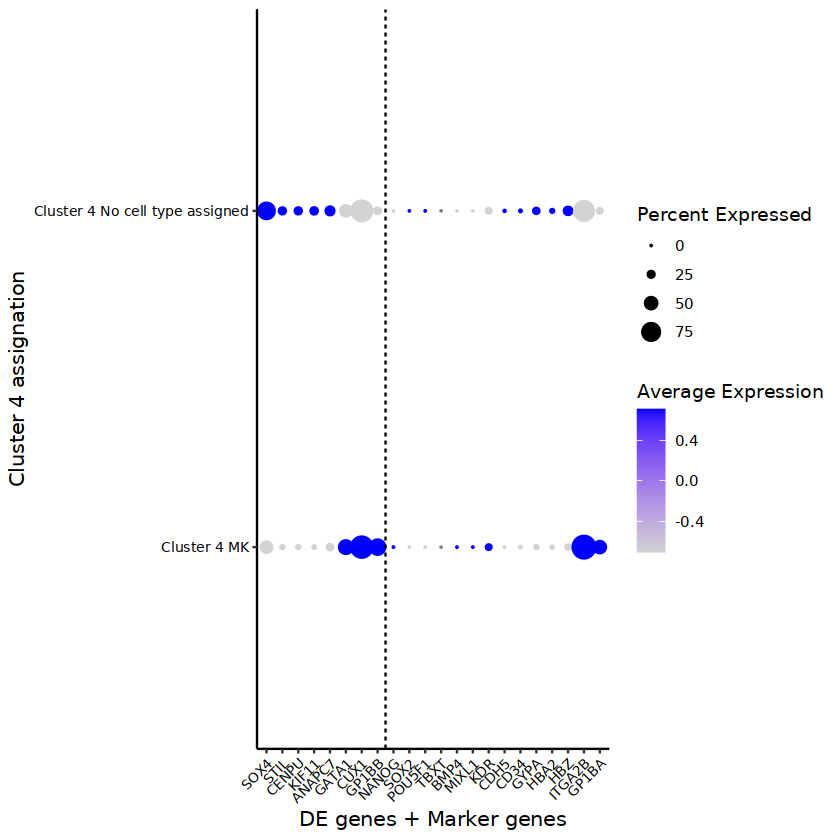

In [247]:
dotplot3<-DotPlot(
  adata_sub,
  features=c('SOX4','STIL','CENPU','KIF11','ANAPC7','GATA1','CUX1','GP1BB',
             "NANOG",'SOX2','POU5F1',"TBXT",'BMP4','MIXL1',"KDR",'CDH5','CD34','GYPA','HBA2','HBZ','ITGA2B','GP1BA'),
  assay = "SCT",
    group.by="FOI")+
ylab('Cluster 4 assignation')+
xlab('DE genes + Marker genes')+
geom_vline(xintercept=8.5, linetype='dashed')+
 theme_classic()+
    theme(axis.title=element_blank(),
          axis.title.y=element_text(color="black", family="sans", size=12),
          axis.title.x=element_text(color="black", family="sans", size=12),
          axis.text.y=element_text(color="black", family="sans", size=8),
          axis.text.x=element_text(angle=45,vjust=1,hjust=1, color="black", family="sans", size=8))


setwd(path_graphs)

svgname<-paste("Dotplot_cluster4_exploration_DE_genes_and_marker_genes",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= dotplot3,
         device="png")
}

dotplot3

# UPDATE My annotation

In [254]:
#colnames(adata@meta.data)

In [255]:
adata@meta.data$my_anot_updated<-as.character(adata@meta.data$my_anot)

In [256]:
adata@meta.data$my_anot_updated[which(row.names(adata@meta.data)%in%met_4_unassigned_CellIDs)]<-'MK polyploidization'

In [257]:
adata@meta.data$my_anot_updated[which(row.names(adata@meta.data)%in%met_2_unassigned_CellIDs)]<-'MEP comitted to MK'

In [259]:
names(summary(as.factor(adata@meta.data$my_anot_updated)))

[1] "early erythroid"       "early MK"              "hESCs"                
 [4] "HSCs"                  "late erythroid"        "MEP"                  
 [7] "MEP comitted to MK"    "MK"                    "MK polyploidization"  
[10] "No cell type assigned"

In [260]:
adata@meta.data$my_anot_updated<-factor(adata@meta.data$my_anot_updated, levels=c('hESCs','HSCs','MEP','MEP comitted to MK',
                                        'early erythroid','late erythroid',
                                        'early MK','MK','MK polyploidization',
                                        'No cell type assigned'), ordered=T)

summary(adata@meta.data$my_anot_updated)

hESCs                  HSCs                   MEP 
                11681                   361                  1251 
   MEP comitted to MK       early erythroid        late erythroid 
                 5059                   730                   176 
             early MK                    MK   MK polyploidization 
                  190                  7800                  3320 
No cell type assigned 
                 6936

### my anot updated vs seurat clusters vs time_point

In [261]:
met<-adata[[]]

In [262]:
met.dt<-data.table(met,key=c("time_point","seurat_clusters","my_anot_updated"))

In [263]:
#str(met.dt)

In [264]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [265]:
met.dt<-data.table(met, key=c("time_point","seurat_clusters"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [266]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("time_point","seurat_clusters"))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [267]:
str(Freq.table)

'data.frame':	98 obs. of  6 variables:
 $ time_point     : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ seurat_clusters: Factor w/ 18 levels "1","2","3","4",..: 1 1 13 13 16 16 18 18 5 5 ...
 $ my_anot_updated: Ord.factor w/ 10 levels "hESCs"<"HSCs"<..: 1 10 1 10 1 10 1 10 1 10 ...
 $ Freq           : int  9488 1269 413 31 245 115 209 23 1121 226 ...
 $ TOTAL          : int  10757 10757 444 444 360 360 232 232 1347 1347 ...
 $ Perc           : num  88.2 11.8 93.02 6.98 68.06 ...


In [268]:
met.dt<-data.table(met, key=c("time_point"))
Freq.time_point<-as.data.frame(met.dt[,.(ntime=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.time_point,
                  by="time_point")

#Freq.table

In [269]:
str(Freq.table)

'data.frame':	98 obs. of  7 variables:
 $ time_point     : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ seurat_clusters: Factor w/ 18 levels "1","2","3","4",..: 1 1 13 13 16 16 18 18 5 5 ...
 $ my_anot_updated: Ord.factor w/ 10 levels "hESCs"<"HSCs"<..: 1 10 1 10 1 10 1 10 1 10 ...
 $ Freq           : int  9488 1269 413 31 245 115 209 23 1121 226 ...
 $ TOTAL          : int  10757 10757 444 444 360 360 232 232 1347 1347 ...
 $ Perc           : num  88.2 11.8 93.02 6.98 68.06 ...
 $ ntime          : int  13520 13520 13520 13520 13520 13520 13520 13520 13520 13520 ...


In [270]:
Freq.TOTAL<-merge(Freq.TOTAL,
                  Freq.time_point,
                  by="time_point")

In [282]:
vector_colors_my_anot_updated<-c(brewer.pal(7, "Set1"),brewer.pal(4, "Set3"),"gray")[c(1:3,8,4:7,11,12)]
vector_colors_my_anot_updated

[1] "#E41A1C" "#377EB8" "#4DAF4A" "#8DD3C7" "#984EA3" "#FF7F00" "#FFFF33"
 [8] "#A65628" "#FB8072" "gray"

In [283]:
library(forcats)
library(cowplot)

-------------------------------------->	0 25 50 75 100


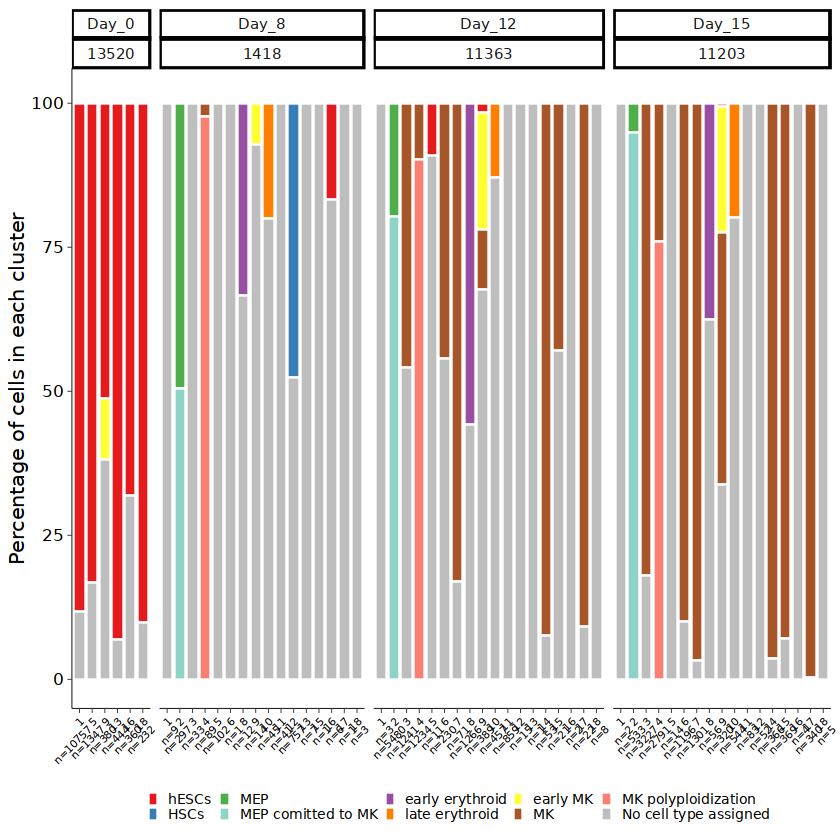

In [284]:
#### Stacked Graph #2---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-Freq.table %>%
    mutate(myaxis = paste0(seurat_clusters, "\n", "n=", TOTAL), drop=F) %>%
    mutate(myaxis=fct_reorder(myaxis,as.numeric(seurat_clusters)), drop=F) %>%
    ggplot(aes(x=myaxis, y=Perc, fill=my_anot_updated)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cluster",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_my_anot_updated,
                      drop=F,
                      name="My Annotation")

 stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ time_point+ntime, scales='free_x', space='free_x', switch="y", labeller=labeller(paste0(Freq.table$time_point, "\n", "n=", Freq.table$ntime)))+   
    scale_x_discrete(name="Seurat clusters", drop=T)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=6),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=6,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=8, color="black", family="sans"),
                  legend.key.size = unit(0.25, 'cm'), #change legend key size
                  legend.key.height = unit(0.25, 'cm'), #change legend key height
                  legend.key.width = unit(0.25, 'cm'), #change legend key width
                  legend.position="bottom")



stacked_barplot

In [285]:
setwd(path_graphs)

svgname<-paste("stacked_barplot_time_point_seurat_clusters_vs_my_anot_updated",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="png",
        width=12, height=6)
}

# Read objects my anot updated

In [3]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

adata<-readRDS(file="merged_processed_presentation_updated.rds")

In [4]:
adata

An object of class Seurat 
445320 features across 37504 samples within 4 assays 
Active assay: SCT (31512 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: RNA, RNA_raw, ATAC
 7 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, umap.wnn, harmony.rna, harmony.atac

In [5]:
colnames(adata@meta.data)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "wsnn_res.0.25"                     "CellTypist_BMA_label"             
[67] "CellTypist_BMA_conf_score"         "CellTypist_IPSCs_label"           
[69] "CellTypist_IPSCs_conf_score"       "CellTypist_BMA_label_filtered"    
[71] "CellTypist_IPSCs_label_filtered"   "time_point"                       
[73] "time"                              "nucleosome_signal"                
[75] "nucleosome_percentile"             "FRiP"                             
[77] "atac_pct_reads_in_peaks"           "my_anot"                          
[79] "FOI"                               "my_anot_updated"

In [23]:
object_for_majority_voting<-adata@meta.data[,c(which(colnames(adata@meta.data)%in%c('seurat_clusters','CellTypist_BMA_label','CellTypist_IPSCs_label')))]

In [25]:
str(object_for_majority_voting)
str(row.names(object_for_majority_voting))

'data.frame':	37504 obs. of  3 variables:
 $ seurat_clusters       : Factor w/ 18 levels "1","2","3","4",..: 1 1 1 9 1 1 1 1 1 13 ...
 $ CellTypist_BMA_label  : chr  "DC3" "DC3" "myelocyte" "myelocyte" ...
 $ CellTypist_IPSCs_label: chr  "iPSCs" "EarlyFibroblasts" "PrimitiveStreak" "iPSCs" ...
 chr [1:37504] "MCO_01326_AAACAGCCACAGCCAT-1" ...


In [26]:
object_for_majority_voting$CellID<-row.names(object_for_majority_voting)

In [27]:
str(object_for_majority_voting)

'data.frame':	37504 obs. of  4 variables:
 $ seurat_clusters       : Factor w/ 18 levels "1","2","3","4",..: 1 1 1 9 1 1 1 1 1 13 ...
 $ CellTypist_BMA_label  : chr  "DC3" "DC3" "myelocyte" "myelocyte" ...
 $ CellTypist_IPSCs_label: chr  "iPSCs" "EarlyFibroblasts" "PrimitiveStreak" "iPSCs" ...
 $ CellID                : chr  "MCO_01326_AAACAGCCACAGCCAT-1" "MCO_01326_AAACAGCCACCAGGTT-1" "MCO_01326_AAACAGCCACGGTACT-1" "MCO_01326_AAACAGCCAGCCGCTA-1" ...


In [28]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

In [29]:
write.csv(object_for_majority_voting, file="Majority_voting_object.csv")

# Read MJ results and add them to the object

In [6]:
MJ<-read.csv("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/Majority_voting_object.csv")

In [7]:
str(MJ)

'data.frame':	37504 obs. of  8 variables:
 $ X                     : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Unnamed..0            : chr  "MCO_01326_AAACAGCCACAGCCAT-1" "MCO_01326_AAACAGCCACCAGGTT-1" "MCO_01326_AAACAGCCACGGTACT-1" "MCO_01326_AAACAGCCAGCCGCTA-1" ...
 $ seurat_clusters       : int  1 1 1 9 1 1 1 1 1 13 ...
 $ CellTypist_BMA_label  : chr  "DC3" "DC3" "myelocyte" "myelocyte" ...
 $ CellTypist_IPSCs_label: chr  "iPSCs" "EarlyFibroblasts" "PrimitiveStreak" "iPSCs" ...
 $ CellID                : chr  "MCO_01326_AAACAGCCACAGCCAT-1" "MCO_01326_AAACAGCCACCAGGTT-1" "MCO_01326_AAACAGCCACGGTACT-1" "MCO_01326_AAACAGCCAGCCGCTA-1" ...
 $ majority_voting_BMA   : chr  "myelocyte" "myelocyte" "myelocyte" "early MK" ...
 $ majority_voting_iPSCs : chr  "iPSCs" "iPSCs" "iPSCs" "Megakaryocytes" ...


In [8]:
MJ_sub<-MJ[,c(which(colnames(MJ)%in%c('majority_voting_BMA','majority_voting_iPSCs')))]
row.names(MJ_sub)<-MJ$Unnamed

str(MJ_sub)
str(row.names(MJ_sub))

'data.frame':	37504 obs. of  2 variables:
 $ majority_voting_BMA  : chr  "myelocyte" "myelocyte" "myelocyte" "early MK" ...
 $ majority_voting_iPSCs: chr  "iPSCs" "iPSCs" "iPSCs" "Megakaryocytes" ...
 chr [1:37504] "MCO_01326_AAACAGCCACAGCCAT-1" ...


In [9]:
adata<-AddMetaData(object=adata, metadata=MJ_sub, col.name=c("majority_voting_BMA","majority_voting_iPSCs"))

### New cell typist plots

In [11]:
path_graphs<-"/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/graphs_FINAL_presentation"

Warning message:
"ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


png 
  2

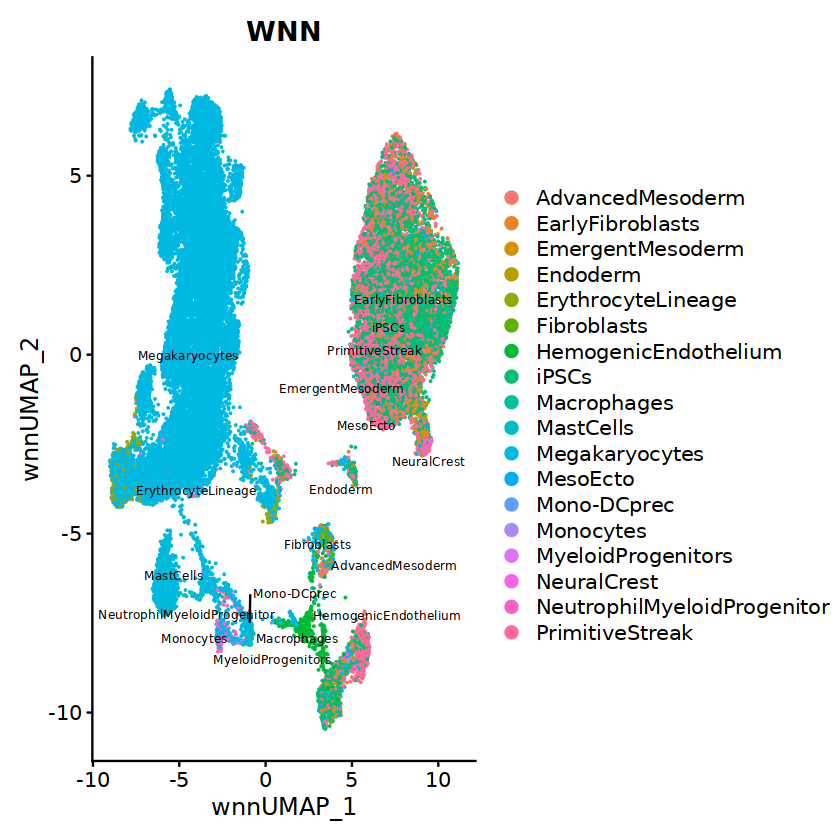

In [16]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "CellTypist_IPSCs_label", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3
setwd(path_graphs)
png(file='WNN_by_CellTypist_IPSCs_label.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

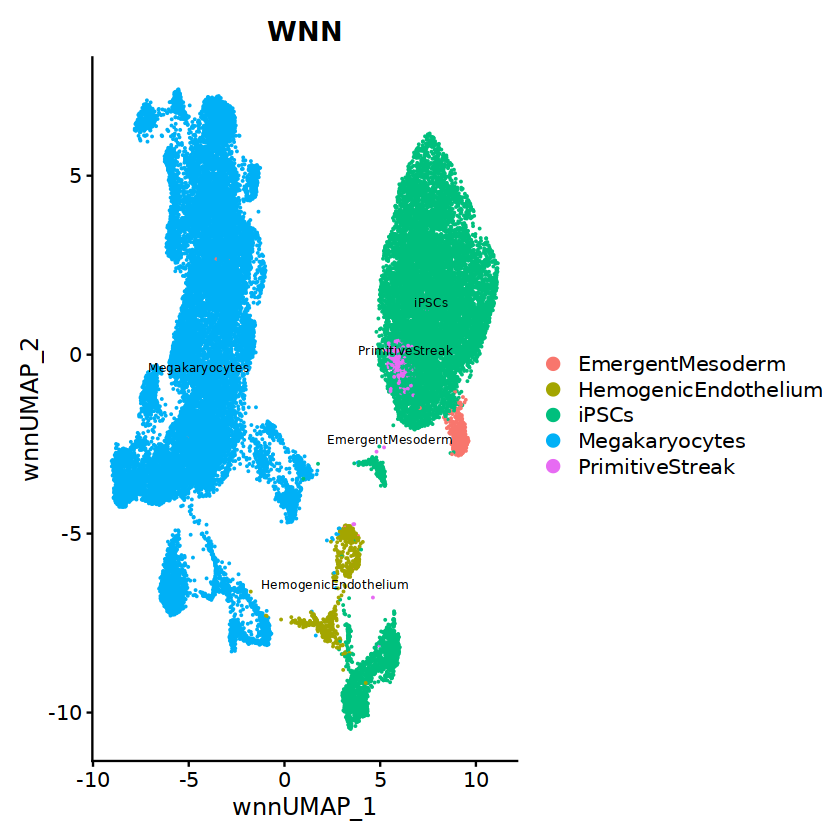

In [18]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "majority_voting_iPSCs", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3
setwd(path_graphs)
png(file='WNN_by_majority_voting_iPSCs.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

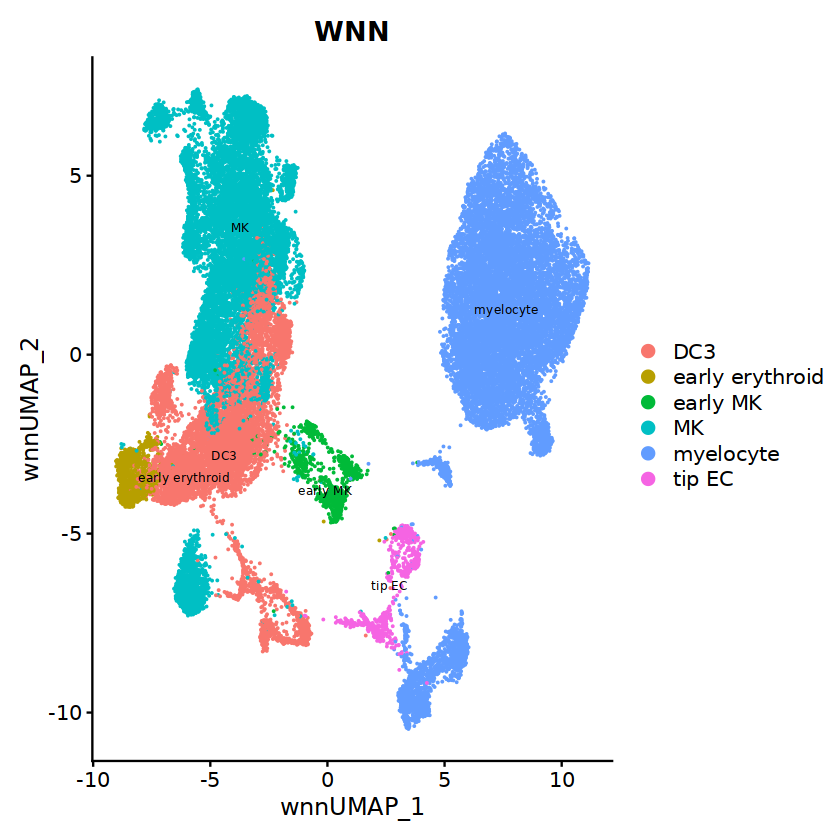

In [19]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "majority_voting_BMA", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3
setwd(path_graphs)
png(file='WNN_by_majority_voting_BMA.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

## my Anot new_update

In [23]:
summary(as.factor(adata@meta.data$majority_voting_BMA))

DC3 early erythroid        early MK              MK       myelocyte 
           8339            1334            1103           12587           13317 
         tip EC 
            824

In [24]:
summary(as.factor(adata@meta.data$majority_voting_iPSCs))

EmergentMesoderm HemogenicEndothelium                iPSCs 
                 372                  824                12493 
      Megakaryocytes      PrimitiveStreak 
               23363                  452

In [21]:
indx.hESC<-which(adata@meta.data$majority_voting_iPSCs%in%c('iPSCs','PrimitiveStreak','EmergentMesoderm'))
indx.HemogenicEndothelium<-which(adata@meta.data$majority_voting_iPSCs%in%c('HemogenicEndothelium'))

In [22]:
adata@meta.data$current_anot<-NA

adata@meta.data$current_anot[indx.hESC]<-'hESC'
adata@meta.data$current_anot[indx.HemogenicEndothelium]<-'HemogenicEndothelium'


In [25]:
indx.earlyMK<-which(adata@meta.data$majority_voting_BMA%in%c('early MK'))
indx.earlyerythroid<-which(adata@meta.data$majority_voting_BMA%in%c('early erythroid'))
indx.MK<-which(adata@meta.data$majority_voting_BMA%in%c('MK'))
indx.MEP<-which(adata@meta.data$majority_voting_BMA%in%c('DC3'))


adata@meta.data$current_anot[indx.earlyMK]<-'early MK'
adata@meta.data$current_anot[indx.earlyerythroid]<-'early erythroid'
adata@meta.data$current_anot[indx.MK]<-'MK'
adata@meta.data$current_anot[indx.MEP]<-'MEP'

In [26]:
summary(as.factor(adata@meta.data$current_anot))

early erythroid             early MK HemogenicEndothelium 
                1334                 1103                  824 
                hESC                  MEP                   MK 
               13317                 8339                12587

In [28]:
adata@meta.data$current_anot<-factor(adata@meta.data$current_anot, levels=c('hESC','HemogenicEndothelium','MEP','early erythroid','early MK','MK'), ordered=T)

In [29]:
summary(adata@meta.data$current_anot)

hESC HemogenicEndothelium                  MEP 
               13317                  824                 8339 
     early erythroid             early MK                   MK 
                1334                 1103                12587

### current_anot vs seurat clusters vs time_point

In [30]:
met<-adata[[]]

In [31]:
met.dt<-data.table(met,key=c("time_point","seurat_clusters","current_anot"))

In [32]:
#str(met.dt)

In [33]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [34]:
met.dt<-data.table(met, key=c("time_point","seurat_clusters"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [35]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("time_point","seurat_clusters"))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [36]:
str(Freq.table)

'data.frame':	57 obs. of  6 variables:
 $ time_point     : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 3 3 3 3 ...
 $ seurat_clusters: Factor w/ 18 levels "1","2","3","4",..: 1 13 16 18 5 9 1 10 11 12 ...
 $ current_anot   : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 1 1 1 1 1 5 1 3 3 2 ...
 $ Freq           : int  10757 444 360 232 1347 380 3 457 859 15 ...
 $ TOTAL          : int  10757 444 360 232 1347 380 3 457 859 15 ...
 $ Perc           : num  100 100 100 100 100 100 100 100 100 100 ...


In [37]:
met.dt<-data.table(met, key=c("time_point"))
Freq.time_point<-as.data.frame(met.dt[,.(ntime=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.time_point,
                  by="time_point")

#Freq.table

In [38]:
str(Freq.table)

'data.frame':	57 obs. of  7 variables:
 $ time_point     : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 3 3 3 3 ...
 $ seurat_clusters: Factor w/ 18 levels "1","2","3","4",..: 1 13 16 18 5 9 1 10 11 12 ...
 $ current_anot   : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 1 1 1 1 1 5 1 3 3 2 ...
 $ Freq           : int  10757 444 360 232 1347 380 3 457 859 15 ...
 $ TOTAL          : int  10757 444 360 232 1347 380 3 457 859 15 ...
 $ Perc           : num  100 100 100 100 100 100 100 100 100 100 ...
 $ ntime          : int  13520 13520 13520 13520 13520 13520 11363 11363 11363 11363 ...


In [39]:
Freq.TOTAL<-merge(Freq.TOTAL,
                  Freq.time_point,
                  by="time_point")

### Filter out clusters in time points when they are less than 100 cells for visualization

In [45]:
summary(Freq.table$TOTAL)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1      11      83     658     457   10757 

In [46]:
Freq.table_filtered<-Freq.table[which(Freq.table$TOTAL >= 100),]

In [47]:
summary(Freq.TOTAL_filtered$TOTAL)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    102     363     533    1364    1254   10757 

In [43]:
vector_colors_current_anot<-c(brewer.pal(7, "Set1"),"gray")

In [44]:
library(forcats)
library(cowplot)


Attaching package: 'cowplot'


The following object is masked from 'package:patchwork':

    align_plots


The following object is masked from 'package:ggpubr':

    get_legend




-------------------------------------->	0 25 50 75 100


Warning message:
"The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead."
Warning message:
"The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead."


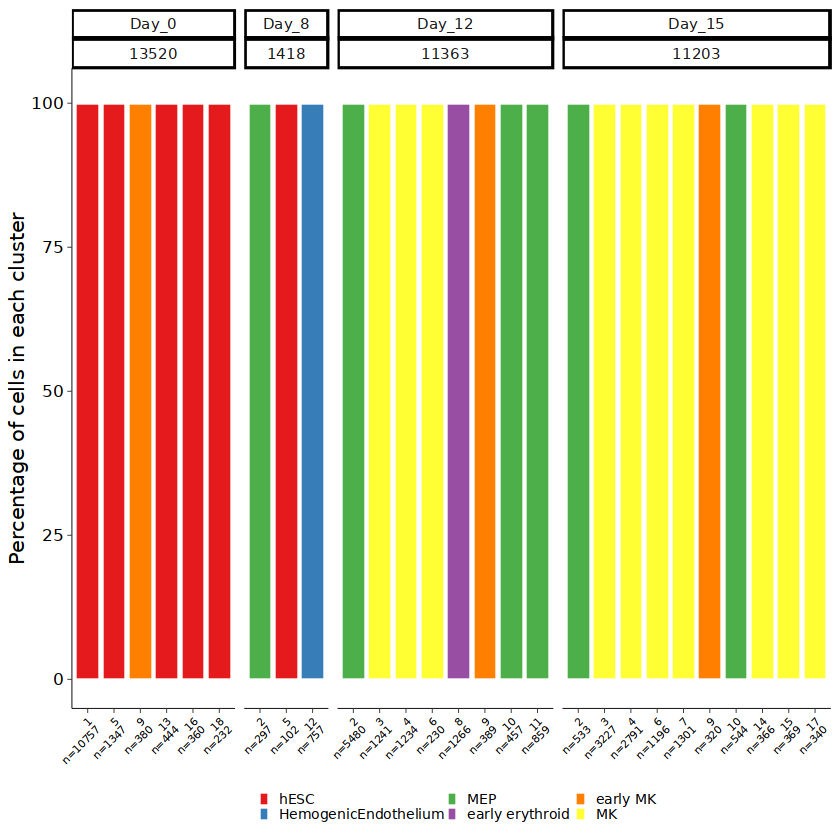

In [48]:
#### Stacked Graph #2---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-Freq.table_filtered %>%
    mutate(myaxis = paste0(seurat_clusters, "\n", "n=", TOTAL), drop=F) %>%
    mutate(myaxis=fct_reorder(myaxis,as.numeric(seurat_clusters)), drop=F) %>%
    ggplot(aes(x=myaxis, y=Perc, fill=current_anot)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cluster",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_current_anot,
                      drop=F,
                      name="My Annotation")

 stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ time_point+ntime, scales='free_x', space='free_x', switch="y", labeller=labeller(paste0(Freq.table_filtered$time_point, "\n", "n=", Freq.table_filtered$ntime)))+   
    scale_x_discrete(name="Seurat clusters", drop=T)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=6),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=6,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=8, color="black", family="sans"),
                  legend.key.size = unit(0.25, 'cm'), #change legend key size
                  legend.key.height = unit(0.25, 'cm'), #change legend key height
                  legend.key.width = unit(0.25, 'cm'), #change legend key width
                  legend.position="bottom")

setwd(path_graphs)

svgname<-paste("stacked_barplot_time_point_seurat_clusters_vs_current_anot",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="png",
        width=12, height=6)
}

stacked_barplot

### NEW Define which subsets of cells from cluster 4 I am interested in comparing

In [123]:
met<-adata[[]]

In [124]:
met_4<-met[which(met$seurat_clusters == '4'),]

In [125]:
summary(droplevels(met_4$my_anot))

MK No cell type assigned 
                  794                  3320

In [126]:
met_4_MK_CellIDs<-row.names(met_4)[which(met_4$my_anot == 'MK')]

str(met_4_MK_CellIDs)

 chr [1:794] "MCO_01327_AGTAATGCATTGCGAC-1" "MCO_01327_CGCCTGTGTAATAGCT-1" ...


In [127]:
met_4_unassigned_CellIDs<-row.names(met_4)[which(met_4$my_anot == 'No cell type assigned')]

str(met_4_unassigned_CellIDs)

 chr [1:3320] "MCO_01327_AAAGGTTAGCCTGATG-1" "MCO_01327_AACCTCACACCACAAC-1" ...


## Add these columns to the metadata

In [128]:
adata@meta.data$FOI<-NA

In [129]:
adata@meta.data$FOI[which(row.names(adata@meta.data)%in%met_4_unassigned_CellIDs)]<-'Cluster 4 No cell type assigned'

In [130]:
adata@meta.data$FOI[which(row.names(adata@meta.data)%in%met_4_MK_CellIDs)]<-'Cluster 4 MK'

In [131]:
adata@meta.data$FOI<-factor(adata@meta.data$FOI, levels=c('Cluster 4 MK','Cluster 4 No cell type assigned'))

In [132]:
summary(adata@meta.data$FOI)

Cluster 4 MK Cluster 4 No cell type assigned 
                            794                            3320 
                           NA's 
                          33390

In [133]:
adata_sub<-subset(adata, FOI != "NA")

Warning message:
"Removing 33390 cells missing data for vars requested"


Warning message:
"Scaling data with a low number of groups may produce misleading results"
Saving 6.67 x 6.67 in image


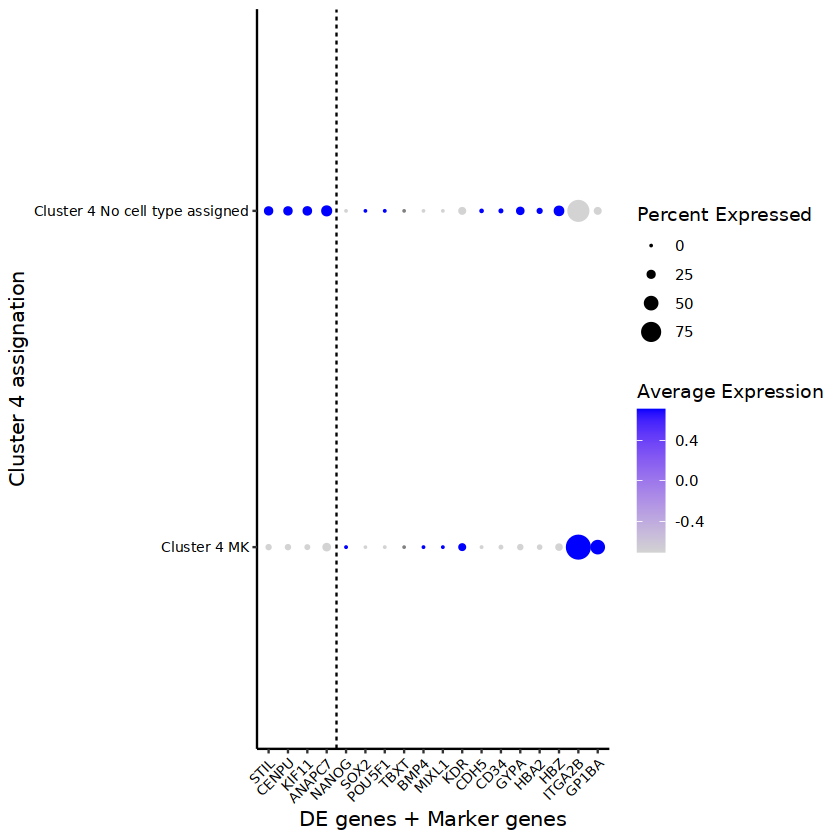

In [61]:
dotplot3<-DotPlot(
  adata_sub,
  features=c('STIL','CENPU','KIF11','ANAPC7',
             "NANOG",'SOX2','POU5F1',"TBXT",'BMP4','MIXL1',"KDR",'CDH5','CD34','GYPA','HBA2','HBZ','ITGA2B','GP1BA'),
  assay = "SCT",
    group.by="FOI")+
ylab('Cluster 4 assignation')+
xlab('DE genes + Marker genes')+
geom_vline(xintercept=4.5, linetype='dashed')+
 theme_classic()+
    theme(axis.title=element_blank(),
          axis.title.y=element_text(color="black", family="sans", size=12),
          axis.title.x=element_text(color="black", family="sans", size=12),
          axis.text.y=element_text(color="black", family="sans", size=8),
          axis.text.x=element_text(angle=45,vjust=1,hjust=1, color="black", family="sans", size=8))


setwd(path_graphs)

svgname<-paste("Dotplot_cluster4_exploration_DE_genes_and_marker_genes_REDUCED",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= dotplot3,
         device="png")
}

dotplot3

Warning message:
"The following requested variables were not found: PLTK"
Warning message:
"Scaling data with a low number of groups may produce misleading results"


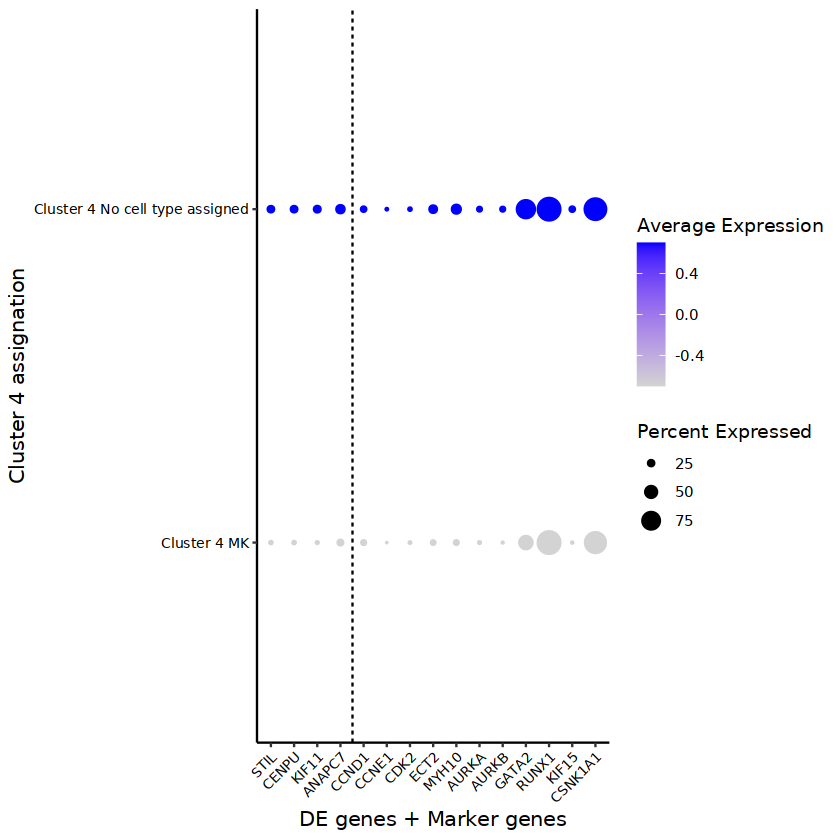

In [140]:
# https://www.sciencedirect.com/science/article/pii/S0301472X17308172

dotplot3<-DotPlot(
  adata_sub,
  features=c('STIL','CENPU','KIF11','ANAPC7',
             "CCND1","CCNE1","CDK2","ECT2","MYH10","AURKA","PLTK","AURKB",
            "GATA2","RUNX1",
            "KIF15","CSNK1A1"),
  assay = "SCT",
    group.by="FOI")+
ylab('Cluster 4 assignation')+
xlab('DE genes + Marker genes')+
geom_vline(xintercept=4.5, linetype='dashed')+
 theme_classic()+
    theme(axis.title=element_blank(),
          axis.title.y=element_text(color="black", family="sans", size=12),
          axis.title.x=element_text(color="black", family="sans", size=12),
          axis.text.y=element_text(color="black", family="sans", size=8),
          axis.text.x=element_text(angle=45,vjust=1,hjust=1, color="black", family="sans", size=8))

dotplot3

# Show the genotype breakdown

## Freq tables genotype factor vs time_point vs current_anot

### genotype clone line vs my anot updated vs time_point

In [62]:
levels(adata@meta.data$Assigned_GFPbc)<-c(levels(adata@meta.data$Assigned_GFPbc),'Genotype missing')

In [63]:
adata@meta.data$Assigned_GFPbc[is.na(adata@meta.data$Assigned_GFPbc)]<-'Genotype missing'

In [64]:
adata@meta.data$Assigned_GFPbc<-droplevels(adata@meta.data$Assigned_GFPbc)
summary(adata@meta.data$Assigned_GFPbc)

chrGFP_WTA       chrGFP_WTB       chrGFP_WTC       chrGFP_rs1 
              14               20               36              118 
      chrGFP_rs2       chrGFP_rs3    chrGFP_R882H1    chrGFP_R882H2 
             134             1629              105                9 
   chrGFP_R882H3 chrGFP_rs_R882H1 chrGFP_rs_R882H2 chrGFP_rs_R882H3 
             109              236               79               80 
Genotype missing 
           34935

In [65]:
met<-adata[[]]

In [66]:
colnames(met)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "wsnn_res.0.25"                     "CellTypist_BMA_label"             
[67] "CellTypist_BMA_conf_score"         "CellTypist_IPSCs_label"           
[69] "CellTypist_IPSCs_conf_score"       "CellTypist_BMA_label_filtered"    
[71] "CellTypist_IPSCs_label_filtered"   "time_point"                       
[73] "time"                              "nucleosome_signal"                
[75] "nucleosome_percentile"             "FRiP"                             
[77] "atac_pct_reads_in_peaks"           "my_anot"                          
[79] "FOI"                               "my_anot_updated"                  
[81] "majority_voting_BMA"               "majority_voting_iPSCs"            
[83] "current_anot"

In [67]:
met.dt<-data.table(met,key=c("time_point","current_anot","Assigned_GFPbc"))

In [68]:
#str(met.dt)

In [69]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [70]:
met.dt<-data.table(met, key=c("time_point","current_anot"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [71]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("time_point","current_anot"))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [72]:
str(Freq.table)

'data.frame':	115 obs. of  6 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 5 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 13 1 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 363 3 ...
 $ TOTAL         : int  380 380 380 380 380 380 380 380 380 13140 ...
 $ Perc          : num  0.26 0.26 0.53 0.26 1.05 ...


In [73]:
met.dt<-data.table(met, key=c("time_point"))
Freq.time_point<-as.data.frame(met.dt[,.(ntime=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.time_point,
                  by="time_point")

#Freq.table

In [74]:
str(Freq.table)

'data.frame':	115 obs. of  7 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 5 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 13 1 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 363 3 ...
 $ TOTAL         : int  380 380 380 380 380 380 380 380 380 13140 ...
 $ Perc          : num  0.26 0.26 0.53 0.26 1.05 ...
 $ ntime         : int  13520 13520 13520 13520 13520 13520 13520 13520 13520 13520 ...


In [75]:
Freq.TOTAL<-merge(Freq.TOTAL,
                  Freq.time_point,
                  by="time_point")

In [77]:
Freq.table_filtered<-Freq.table[which(Freq.table$TOTAL >= 100),]

str(Freq.table_filtered)

'data.frame':	99 obs. of  7 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 5 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 13 1 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 363 3 ...
 $ TOTAL         : int  380 380 380 380 380 380 380 380 380 13140 ...
 $ Perc          : num  0.26 0.26 0.53 0.26 1.05 ...
 $ ntime         : int  13520 13520 13520 13520 13520 13520 13520 13520 13520 13520 ...


In [78]:
vector_colors_clone_lines<-c(brewer.pal(12, "Set3"),"gray")
vector_colors_clone_lines

[1] "#8DD3C7" "#FFFFB3" "#BEBADA" "#FB8072" "#80B1D3" "#FDB462" "#B3DE69"
 [8] "#FCCDE5" "#D9D9D9" "#BC80BD" "#CCEBC5" "#FFED6F" "gray"

In [79]:
library(forcats)
library(cowplot)

-------------------------------------->	0 25 50 75 100


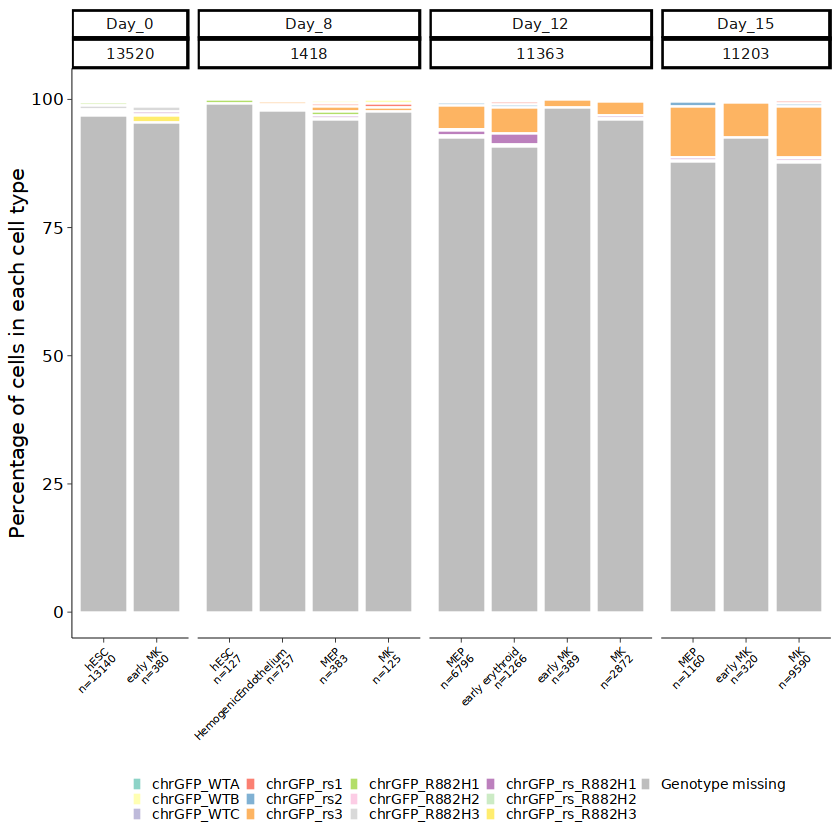

In [80]:
#### Stacked Graph #2---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-Freq.table_filtered %>%
    mutate(myaxis = paste0(current_anot, "\n", "n=", TOTAL), drop=F) %>%
    mutate(myaxis=fct_reorder(myaxis,as.numeric(current_anot)), drop=F) %>%
    ggplot(aes(x=myaxis, y=Perc, fill=Assigned_GFPbc)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cell type",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_clone_lines,
                      drop=F,
                      name="My Annotation")

 stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ time_point+ntime, scales='free_x', space='free_x', switch="y", labeller=labeller(paste0(Freq.table_filtered$time_point, "\n", "n=", Freq.table_filtered$ntime)))+   
    scale_x_discrete(name="Seurat clusters", drop=T)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=6),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=6,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=8, color="black", family="sans"),
                  legend.key.size = unit(0.25, 'cm'), #change legend key size
                  legend.key.height = unit(0.25, 'cm'), #change legend key height
                  legend.key.width = unit(0.25, 'cm'), #change legend key width
                  legend.position="bottom")



stacked_barplot

In [81]:
setwd(path_graphs)

svgname<-paste("stacked_barplot_time_point_current_anot_vs_Assigned_GFPbc",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="png",
        width=12, height=6)
}

## subset for the cells that are genotyped

In [99]:
adata_sub<-subset(adata, Assigned_GFPbc != "Genotype missing")

In [100]:
met<-adata_sub[[]]

In [101]:
colnames(met)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "wsnn_res.0.25"                     "CellTypist_BMA_label"             
[67] "CellTypist_BMA_conf_score"         "CellTypist_IPSCs_label"           
[69] "CellTypist_IPSCs_conf_score"       "CellTypist_BMA_label_filtered"    
[71] "CellTypist_IPSCs_label_filtered"   "time_point"                       
[73] "time"                              "nucleosome_signal"                
[75] "nucleosome_percentile"             "FRiP"                             
[77] "atac_pct_reads_in_peaks"           "my_anot"                          
[79] "FOI"                               "my_anot_updated"                  
[81] "majority_voting_BMA"               "majority_voting_iPSCs"            
[83] "current_anot"

In [102]:
met.dt<-data.table(met,key=c("time_point","current_anot","Assigned_GFPbc"))

In [103]:
#str(met.dt)

In [104]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [105]:
met.dt<-data.table(met, key=c("time_point","current_anot"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [106]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("time_point","current_anot"))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [107]:
str(Freq.table)

'data.frame':	95 obs. of  6 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 1 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 1 2 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 3 10 ...
 $ TOTAL         : int  17 17 17 17 17 17 17 17 419 419 ...
 $ Perc          : num  5.88 5.88 11.76 5.88 23.53 ...


In [108]:
met.dt<-data.table(met, key=c("time_point"))
Freq.time_point<-as.data.frame(met.dt[,.(ntime=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.time_point,
                  by="time_point")

#Freq.table

In [109]:
str(Freq.table)

'data.frame':	95 obs. of  7 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 1 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 1 2 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 3 10 ...
 $ TOTAL         : int  17 17 17 17 17 17 17 17 419 419 ...
 $ Perc          : num  5.88 5.88 11.76 5.88 23.53 ...
 $ ntime         : int  436 436 436 436 436 436 436 436 436 436 ...


In [110]:
Freq.TOTAL<-merge(Freq.TOTAL,
                  Freq.time_point,
                  by="time_point")

In [116]:
Freq.table_filtered<-Freq.table[which(Freq.table$TOTAL >= 3),]

str(Freq.table_filtered)

'data.frame':	93 obs. of  7 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 1 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 1 2 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 3 10 ...
 $ TOTAL         : int  17 17 17 17 17 17 17 17 419 419 ...
 $ Perc          : num  5.88 5.88 11.76 5.88 23.53 ...
 $ ntime         : int  436 436 436 436 436 436 436 436 436 436 ...


In [117]:
vector_colors_clone_lines<-c(brewer.pal(12, "Set3"),"gray")
vector_colors_clone_lines

[1] "#8DD3C7" "#FFFFB3" "#BEBADA" "#FB8072" "#80B1D3" "#FDB462" "#B3DE69"
 [8] "#FCCDE5" "#D9D9D9" "#BC80BD" "#CCEBC5" "#FFED6F" "gray"

In [118]:
library(forcats)
library(cowplot)

-------------------------------------->	0 25 50 75 100


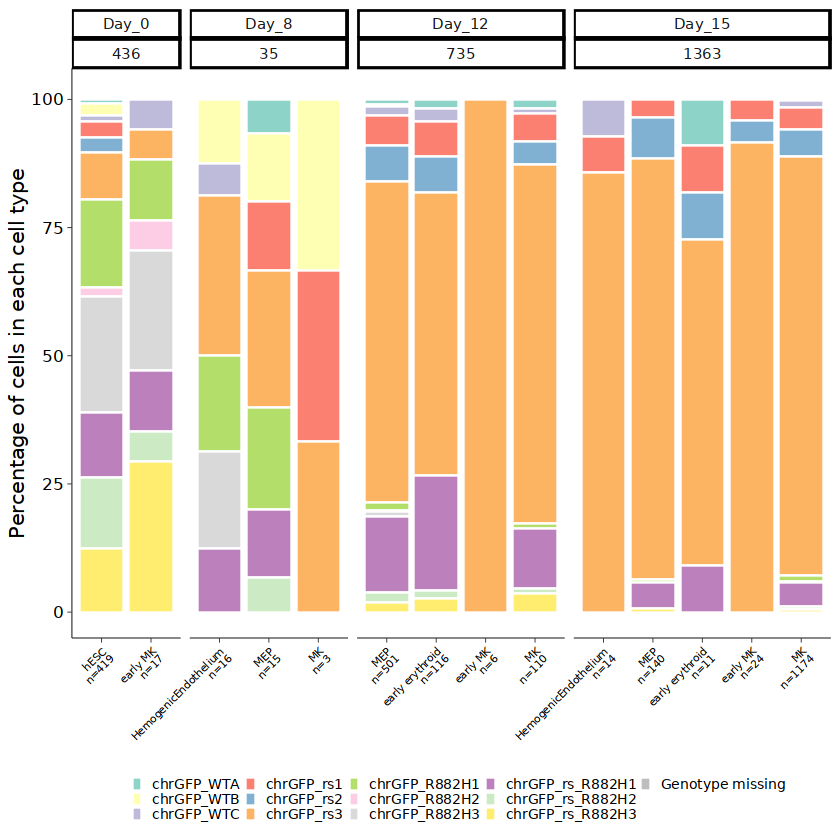

In [119]:
#### Stacked Graph #2---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-Freq.table_filtered %>%
    mutate(myaxis = paste0(current_anot, "\n", "n=", TOTAL), drop=F) %>%
    mutate(myaxis=fct_reorder(myaxis,as.numeric(current_anot)), drop=F) %>%
    ggplot(aes(x=myaxis, y=Perc, fill=Assigned_GFPbc)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cell type",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_clone_lines,
                      drop=F,
                      name="My Annotation")

 stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ time_point+ntime, scales='free_x', space='free_x', switch="y", labeller=labeller(paste0(Freq.table_filtered$time_point, "\n", "n=", Freq.table_filtered$ntime)))+   
    scale_x_discrete(name="Seurat clusters", drop=T)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=6),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=6,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=8, color="black", family="sans"),
                  legend.key.size = unit(0.25, 'cm'), #change legend key size
                  legend.key.height = unit(0.25, 'cm'), #change legend key height
                  legend.key.width = unit(0.25, 'cm'), #change legend key width
                  legend.position="bottom")



stacked_barplot

In [120]:
setwd(path_graphs)

svgname<-paste("stacked_barplot_time_point_current_anot_vs_Assigned_GFPbc_restricted_to_genotyped_cells",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="png",
        width=12, height=6)
}

# SAVE

In [121]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

saveRDS(adata,file="merged_processed_presentation_updated.rds")

# Checkpoint after presentation

In [2]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

adata<-readRDS(file="merged_processed_presentation_updated.rds")

## Read each of the files in Seurat

In [23]:
 ###### Read raw data -------
  
  inputdata.10x         <- Read10X_h5(file.path("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/GEX_reseq/alignment/cellranger/MCO_01326/outs/", 'raw_feature_bc_matrix.h5'))
  
  cat("inputdata.10x_0\n")
  cat(str(inputdata.10x))
  cat("\n")
  
  rna_counts            <- inputdata.10x$x

str(rna_counts)



inputdata.10x_0
Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  ..@ i       : int [1:417779] 4 0 6 8 9 10 11 6 2 10 ...
  ..@ p       : int [1:132581] 0 0 1 6 7 7 8 10 11 12 ...
  ..@ Dim     : int [1:2] 12 132580
  ..@ Dimnames:List of 2
  .. ..$ : chr [1:12] "GFP_chrGFP_WTA" "GFP_chrGFP_WTB" "GFP_chrGFP_WTC" "GFP_chrGFP_rs1" ...
  .. ..$ : chr [1:132580] "AAACAGCCAAAGCCTC-1" "AAACAGCCAAAGGTAC-1" "AAACAGCCAAATACCT-1" "AAACAGCCAACACCTA-1" ...
  ..@ x       : num [1:417779] 1 1 1 1 1 1 1 1 1 2 ...
  ..@ factors : list()



ERROR: Error in inputdata.10x$x: $ operator not defined for this S4 class


In [34]:
 adata_samp_1                 <- CreateSeuratObject(counts=Read10X_h5(file.path("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/GEX_reseq/alignment/cellranger/MCO_01326/outs/", 'raw_feature_bc_matrix.h5')))
  
 adata_samp_1$orig.ident<-'MCO_01326'

adata_samp_2                 <- CreateSeuratObject(counts=Read10X_h5(file.path("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/GEX_reseq/alignment/cellranger/MCO_01327/outs/", 'raw_feature_bc_matrix.h5')))
  
adata_samp_2$orig.ident<-'MCO_01327'


adata_samp_3                 <- CreateSeuratObject(counts=Read10X_h5(file.path("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/GEX_reseq/alignment/cellranger/MCO_01328/outs/", 'raw_feature_bc_matrix.h5')))
  
 
adata_samp_3$orig.ident<-'MCO_01328'

adata_samp_4                 <- CreateSeuratObject(counts=Read10X_h5(file.path("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/GEX_reseq/alignment/cellranger/MCO_01329/outs/", 'raw_feature_bc_matrix.h5')))
  
adata_samp_4$orig.ident<-'MCO_01329'


Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


In [26]:
lib_CellIDs<-row.names(adata_samp_1@meta.data)

str(lib_CellIDs)

 chr [1:132580] "AAACAGCCAAAGCCTC-1" "AAACAGCCAAAGGTAC-1" ...


In [27]:
 check_1                 <- CreateSeuratObject(counts=Read10X_h5(file.path("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/MCO_01326/outs/", 'raw_feature_bc_matrix.h5')))


Genome matrix has multiple modalities, returning a list of matrices for this genome



In [28]:
exp_CellIDs<-row.names(check_1@meta.data)

str(exp_CellIDs)

 chr [1:734627] "AAACAGCCAAACAACA-1" "AAACAGCCAAACATAG-1" ...


In [29]:
ov<-which(exp_CellIDs%in%lib_CellIDs)

str(ov)

 int [1:132575] 12 18 19 25 34 35 41 47 50 52 ...


In [35]:
adatas<-list()

adatas[[1]]<-adata_samp_1
adatas[[2]]<-adata_samp_2
adatas[[3]]<-adata_samp_3
adatas[[4]]<-adata_samp_4



In [36]:
sample_array<-c('MCO_01326','MCO_01327','MCO_01328','MCO_01329')

In [38]:
 merged = merge(x =adatas[[1]], y=adatas[2:4], add.cell.ids = sample_array )
  
  
  
  merged[["RNA"]] <-JoinLayers(merged[["RNA"]])
  
 

In [39]:
colnames(merged@meta.data)

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA"

In [40]:
merged_filt<-subset(merged, nFeature_RNA > 0)

In [42]:
str(merged_filt@meta.data)
str(row.names(merged_filt@meta.data))

'data.frame':	406230 obs. of  3 variables:
 $ orig.ident  : chr  "MCO_01326" "MCO_01326" "MCO_01326" "MCO_01326" ...
 $ nCount_RNA  : num  1 5 1 1 3 1 1 2 1 1 ...
 $ nFeature_RNA: int  1 5 1 1 2 1 1 1 1 1 ...
 chr [1:406230] "MCO_01326_AAACAGCCAAAGGTAC-1" ...


In [43]:
lib_CellIDs<-row.names(merged_filt@meta.data)

str(lib_CellIDs)

 chr [1:406230] "MCO_01326_AAACAGCCAAAGGTAC-1" ...


In [44]:
exp_CellIDs<-row.names(adata@meta.data)

str(exp_CellIDs)

 chr [1:37504] "MCO_01326_AAACAGCCACAGCCAT-1" ...


In [45]:
ov<-which(exp_CellIDs%in%lib_CellIDs)

str(ov)

 int [1:37482] 1 2 3 4 5 6 7 8 9 10 ...


In [47]:
merged_filt@meta.data$cells_in_Seurat_object<-NA

In [48]:
merged_filt@meta.data$cells_in_Seurat_object[which(row.names(merged_filt@meta.data)%in%row.names(adata@meta.data))]<-'cells_in_Seurat_object'

In [49]:
merged_filt@meta.data$cells_in_Seurat_object[-which(row.names(merged_filt@meta.data)%in%row.names(adata@meta.data))]<-'cells_not_in_Seurat_object'

In [50]:
merged_filt

An object of class Seurat 
12 features across 406230 samples within 1 assay 
Active assay: RNA (12 features, 0 variable features)
 1 layer present: counts

In [52]:
merged_filt_cells<-subset(merged_filt, cells_in_Seurat_object == 'cells_in_Seurat_object')

In [53]:
genes<-Features(merged_filt_cells)

genes

[1] "GFP-chrGFP-WTA"       "GFP-chrGFP-WTB"       "GFP-chrGFP-WTC"      
 [4] "GFP-chrGFP-rs1"       "GFP-chrGFP-rs2"       "GFP-chrGFP-rs3"      
 [7] "GFP-chrGFP-R882H1"    "GFP-chrGFP-R882H2"    "GFP-chrGFP-R882H3"   
[10] "GFP-chrGFP-rs-R882H1" "GFP-chrGFP-rs-R882H2" "GFP-chrGFP-rs-R882H3"

In [62]:
matrix_RNA<-FetchData(merged_filt_cells, vars = genes, layer= "counts")

In [64]:
str(matrix_RNA)
str(row.names(matrix_RNA))

'data.frame':	37482 obs. of  12 variables:
 $ GFP-chrGFP-WTA      : num  0 0 1 0 0 0 0 1 0 1 ...
 $ GFP-chrGFP-WTB      : num  0 0 1 1 0 0 0 1 2 0 ...
 $ GFP-chrGFP-WTC      : num  0 0 0 1 1 0 0 0 0 2 ...
 $ GFP-chrGFP-rs1      : num  1 0 1 0 16 1 1 0 1 1 ...
 $ GFP-chrGFP-rs2      : num  0 0 0 1 1 0 0 4 0 0 ...
 $ GFP-chrGFP-rs3      : num  1 0 1 0 1 1 1 2 12 2 ...
 $ GFP-chrGFP-R882H1   : num  3 0 3 1 1 1 21 2 1 14 ...
 $ GFP-chrGFP-R882H2   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ GFP-chrGFP-R882H3   : num  28 1 2 4 6 1 3 3 8 3 ...
 $ GFP-chrGFP-rs-R882H1: num  3 0 2 3 3 1 2 1 4 3 ...
 $ GFP-chrGFP-rs-R882H2: num  2 1 1 1 1 1 1 2 3 4 ...
 $ GFP-chrGFP-rs-R882H3: num  3 2 2 7 0 0 3 2 3 2 ...
 chr [1:37482] "MCO_01326_AAACAGCCACAGCCAT-1" ...


In [65]:
matrix_RNA$CellID<-row.names(matrix_RNA)

In [68]:
matrix_RNA.m<-melt(matrix_RNA, id.vars="CellID", variable.name="gene", value.name="counts")

Warning message in melt(matrix_RNA, id.vars = "CellID", variable.name = "gene", :
"The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(matrix_RNA). In the next version, this warning will become an error."


In [69]:
str(matrix_RNA.m)

'data.frame':	449784 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACAGCCACAGCCAT-1" "MCO_01326_AAACAGCCACCAGGTT-1" "MCO_01326_AAACAGCCACGGTACT-1" "MCO_01326_AAACAGCCAGCCGCTA-1" ...
 $ gene  : Factor w/ 12 levels "GFP-chrGFP-WTA",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ counts: num  0 0 1 0 0 0 0 1 0 1 ...


# HERE HERE

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


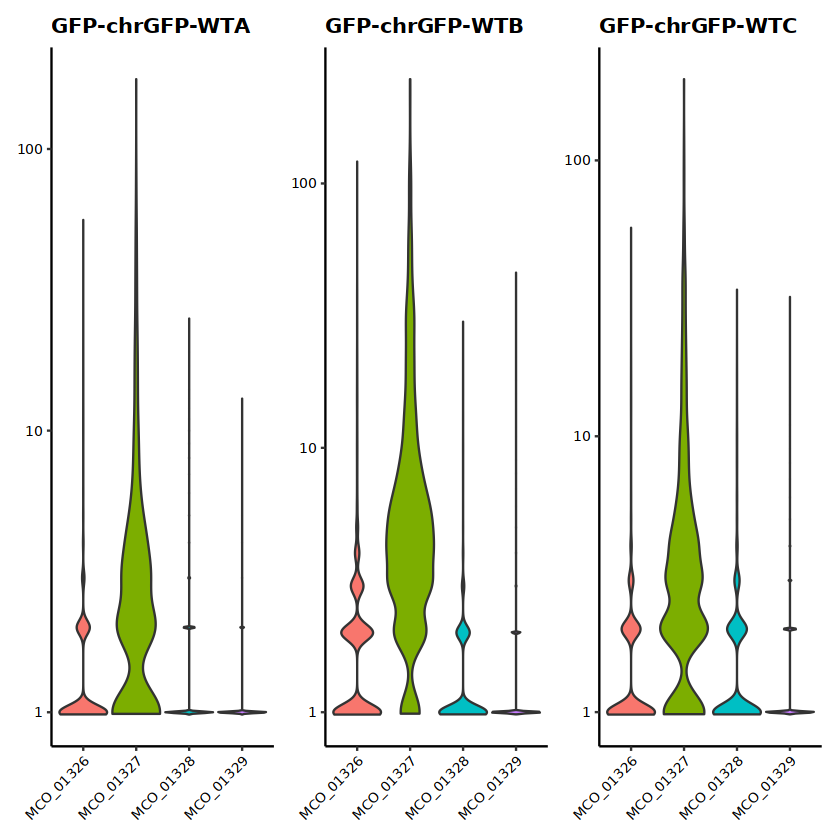

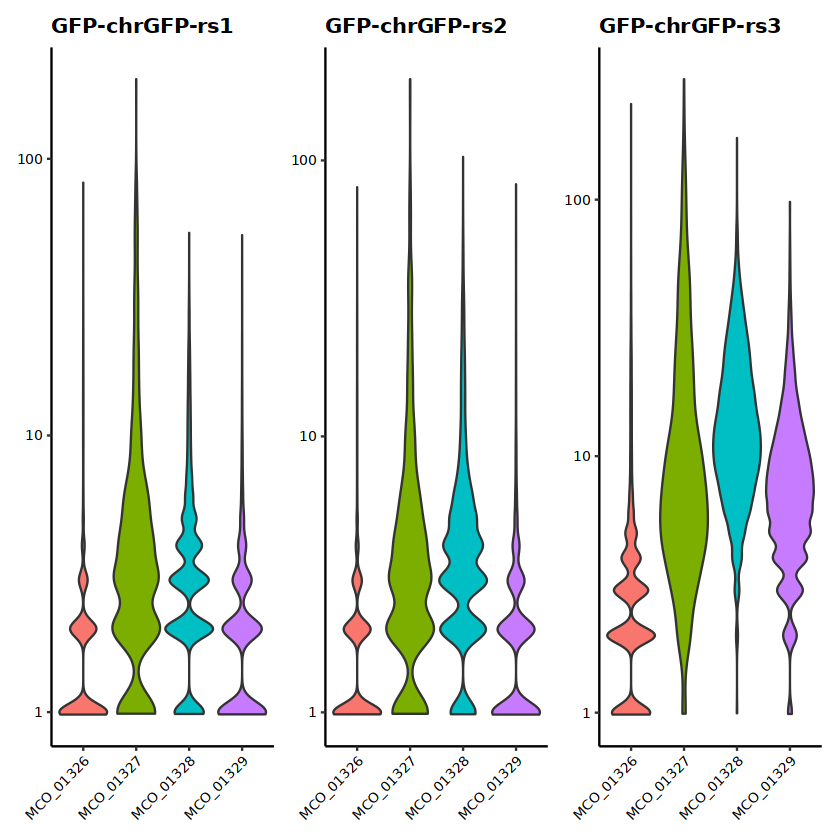

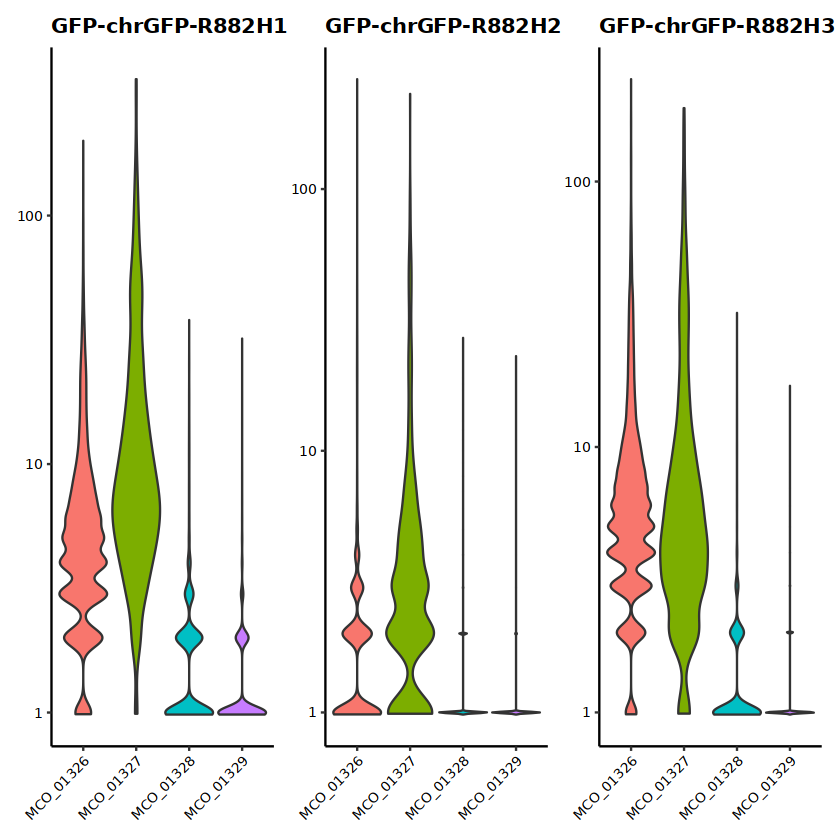

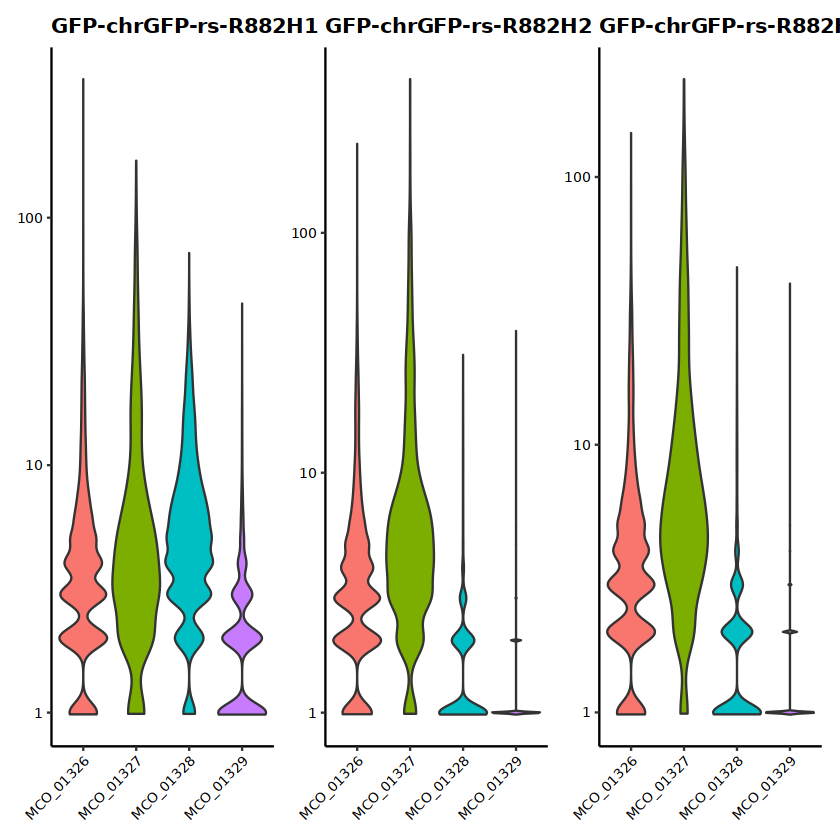

In [82]:
DefaultAssay(merged_filt_cells) <- 'RNA'


Vln_file_1<-VlnPlot(merged_filt_cells, features = genes,  
          ncol = 12,
                    group.by='orig.ident',
          log = TRUE, pt.size = 0)+ NoLegend()


List_Vln<-lapply(Vln_file_1 %>% seq, function(i) { Vln_file_1[[i]] & theme_classic()+
        theme(plot.title=element_text(color="black",face="bold", family="sans", size=12),
              axis.title.y=element_blank(),
              axis.title.x=element_blank(),
              axis.text.y=element_text(color="black", family="sans", size=8),
              axis.text.x=element_text(angle=45,color="black",vjust=1,hjust=1, family="sans", size=8)) +      
        theme(legend.title = element_blank(),
                      legend.text = element_text(color="black", family="sans"),
                      legend.key.size = unit(0.25, 'cm'), #change legend key size
                      legend.key.height = unit(0.25, 'cm'), #change legend key height
                      legend.key.width = unit(0.25, 'cm'), #change legend key width
                      legend.position="hidden")                                 
                                       })







List_Vln[[1]] | List_Vln[[2]] | List_Vln[[3]]  
List_Vln[[4]] | List_Vln[[5]] | List_Vln[[6]]
List_Vln[[7]] | List_Vln[[8]] | List_Vln[[9]]
List_Vln[[10]] | List_Vln[[11]] | List_Vln[[12]]



## Implement a filter to discard background

In [124]:
matrix_RNA.m_filtered<-matrix_RNA.m[which(matrix_RNA.m$counts > 3),]

In [125]:
str(matrix_RNA.m_filtered)

'data.frame':	78830 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACCGCGTGATCATG-1" "MCO_01326_AAAGCGGGTTTAGTCC-1" "MCO_01326_AACCTTAAGCAAGGTA-1" "MCO_01326_AAGCCTCCAATACTGT-1" ...
 $ gene  : Factor w/ 12 levels "GFP-chrGFP-WTA",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ counts: num  9 7 6 9 20 13 4 10 9 8 ...


In [126]:
matrix_RNA.m_filtered<-matrix_RNA.m_filtered[order(matrix_RNA.m_filtered$CellID,matrix_RNA.m_filtered$gene),]

In [127]:
matrix_RNA.m_filtered.dt<-data.table(matrix_RNA.m_filtered, key="CellID")


collapsed<-as.data.frame(matrix_RNA.m_filtered.dt[,.(string=paste(gene, collapse=";"),
                                                    n=length(gene)), by=key(matrix_RNA.m_filtered.dt)])

In [128]:
str(collapsed)
str(collapsed[which(collapsed$n == 1),])
summary(as.factor(collapsed$string[which(collapsed$n == 1)]))

'data.frame':	33033 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACAGCCACAGCCAT-1" "MCO_01326_AAACAGCCAGCCGCTA-1" "MCO_01326_AAACAGCCAGGAAGCC-1" "MCO_01326_AAACAGCCAGTATGTT-1" ...
 $ string: chr  "GFP-chrGFP-R882H3" "GFP-chrGFP-R882H3;GFP-chrGFP-rs-R882H3" "GFP-chrGFP-rs1;GFP-chrGFP-R882H3" "GFP-chrGFP-R882H1" ...
 $ n     : int  1 2 2 1 1 3 2 3 1 2 ...
'data.frame':	12347 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACAGCCACAGCCAT-1" "MCO_01326_AAACAGCCAGTATGTT-1" "MCO_01326_AAACAGCCATCCTAGA-1" "MCO_01326_AAACATGCAATATGGA-1" ...
 $ string: chr  "GFP-chrGFP-R882H3" "GFP-chrGFP-R882H1" "GFP-chrGFP-rs2" "GFP-chrGFP-rs-R882H2" ...
 $ n     : int  1 1 1 1 1 1 1 1 1 1 ...


GFP-chrGFP-R882H1    GFP-chrGFP-R882H2    GFP-chrGFP-R882H3 
                 677                   23                 1144 
GFP-chrGFP-rs-R882H1 GFP-chrGFP-rs-R882H2 GFP-chrGFP-rs-R882H3 
                 548                  244                  269 
      GFP-chrGFP-rs1       GFP-chrGFP-rs2       GFP-chrGFP-rs3 
                 170                  148                 9000 
      GFP-chrGFP-WTA       GFP-chrGFP-WTB       GFP-chrGFP-WTC 
                  26                   52                   46

In [130]:
genotyped_1<-collapsed[which(collapsed$n == 1),]
str(genotyped_1)

'data.frame':	12347 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACAGCCACAGCCAT-1" "MCO_01326_AAACAGCCAGTATGTT-1" "MCO_01326_AAACAGCCATCCTAGA-1" "MCO_01326_AAACATGCAATATGGA-1" ...
 $ string: chr  "GFP-chrGFP-R882H3" "GFP-chrGFP-R882H1" "GFP-chrGFP-rs2" "GFP-chrGFP-rs-R882H2" ...
 $ n     : int  1 1 1 1 1 1 1 1 1 1 ...


In [132]:
not_genotyped<-collapsed[which(collapsed$n != 1),]

str(not_genotyped)

'data.frame':	20686 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACAGCCAGCCGCTA-1" "MCO_01326_AAACAGCCAGGAAGCC-1" "MCO_01326_AAACAGCCATTGTCCT-1" "MCO_01326_AAACATGCAAACGCGA-1" ...
 $ string: chr  "GFP-chrGFP-R882H3;GFP-chrGFP-rs-R882H3" "GFP-chrGFP-rs1;GFP-chrGFP-R882H3" "GFP-chrGFP-rs3;GFP-chrGFP-R882H3;GFP-chrGFP-rs-R882H1" "GFP-chrGFP-R882H1;GFP-chrGFP-rs-R882H2" ...
 $ n     : int  2 2 3 2 3 2 4 2 2 4 ...


In [133]:
matrix_RNA.m_filtered_2<-matrix_RNA.m[which(matrix_RNA.m$counts > 7 & matrix_RNA.m$CellID%in%not_genotyped$CellID),]

In [134]:
str(matrix_RNA.m_filtered_2)

'data.frame':	29740 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACCGCGTGATCATG-1" "MCO_01326_AAGCCTCCAATACTGT-1" "MCO_01326_AAGCGTTTCACGCGGT-1" "MCO_01326_AATAGCTGTTTGCGAA-1" ...
 $ gene  : Factor w/ 12 levels "GFP-chrGFP-WTA",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ counts: num  9 9 20 13 10 9 8 10 10 12 ...


In [135]:
matrix_RNA.m_filtered_2<-matrix_RNA.m_filtered_2[order(matrix_RNA.m_filtered_2$CellID,matrix_RNA.m_filtered_2$gene),]

In [136]:
matrix_RNA.m_filtered.dt<-data.table(matrix_RNA.m_filtered_2, key="CellID")


collapsed<-as.data.frame(matrix_RNA.m_filtered.dt[,.(string=paste(gene, collapse=";"),
                                                    n=length(gene)), by=key(matrix_RNA.m_filtered.dt)])

In [137]:
str(collapsed)
str(collapsed[which(collapsed$n == 1),])
summary(as.factor(collapsed$string[which(collapsed$n == 1)]))

'data.frame':	16904 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACAGCCAGGAAGCC-1" "MCO_01326_AAACAGCCATTGTCCT-1" "MCO_01326_AAACATGCAAACGCGA-1" "MCO_01326_AAACATGCAACCCTAA-1" ...
 $ string: chr  "GFP-chrGFP-rs1" "GFP-chrGFP-rs3;GFP-chrGFP-R882H3" "GFP-chrGFP-R882H1" "GFP-chrGFP-R882H1" ...
 $ n     : int  1 2 1 1 1 1 1 1 1 1 ...
'data.frame':	9515 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACAGCCAGGAAGCC-1" "MCO_01326_AAACATGCAAACGCGA-1" "MCO_01326_AAACATGCAACCCTAA-1" "MCO_01326_AAACATGCACCTAAGC-1" ...
 $ string: chr  "GFP-chrGFP-rs1" "GFP-chrGFP-R882H1" "GFP-chrGFP-R882H1" "GFP-chrGFP-R882H1" ...
 $ n     : int  1 1 1 1 1 1 1 1 1 1 ...


GFP-chrGFP-R882H1    GFP-chrGFP-R882H2    GFP-chrGFP-R882H3 
                 862                   94                  986 
GFP-chrGFP-rs-R882H1 GFP-chrGFP-rs-R882H2 GFP-chrGFP-rs-R882H3 
                1067                  520                  610 
      GFP-chrGFP-rs1       GFP-chrGFP-rs2       GFP-chrGFP-rs3 
                 448                  384                 4164 
      GFP-chrGFP-WTA       GFP-chrGFP-WTB       GFP-chrGFP-WTC 
                  80                  158                  142

In [138]:
genotyped_2<-collapsed[which(collapsed$n == 1),]
str(genotyped_2)

'data.frame':	9515 obs. of  3 variables:
 $ CellID: chr  "MCO_01326_AAACAGCCAGGAAGCC-1" "MCO_01326_AAACATGCAAACGCGA-1" "MCO_01326_AAACATGCAACCCTAA-1" "MCO_01326_AAACATGCACCTAAGC-1" ...
 $ string: chr  "GFP-chrGFP-rs1" "GFP-chrGFP-R882H1" "GFP-chrGFP-R882H1" "GFP-chrGFP-R882H1" ...
 $ n     : int  1 1 1 1 1 1 1 1 1 1 ...


In [72]:
line_plot<-ggplot(matrix_RNA.m, aes(x=gene, y=count)) +
  geom_line( color="#69b3a2", size=2, alpha=0.9, linetype=2) +
  theme_classic() +
  ggtitle("count of barcodes per cell")

In [73]:
line_plot

Don't know how to automatically pick scale for object of type <function>. Defaulting to continuous.
ERROR while rich displaying an object: Error in `geom_line()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error in `compute_aesthetics()`:
! Aesthetics are not valid data columns.
✖ The following aesthetics are invalid:
✖ `y = count`
ℹ Did you mistype the name of a data column or forget to add `after_stat()`?

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (

# Read the NEW genotyping and filter by minimum number of UMIs supporting the genotyped Bc

In [3]:
Uniquely_genotyped_larry_barcodes_assignments<-readRDS("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/GEX_reseq/alignment/cellranger/deconvolute_LARRY/Uniquely_genotyped_larry_barcodes_assignments.rds")

In [12]:
Uniquely_genotyped_larry_barcodes_assignments<-readRDS("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/deconvolute_LARRY/count_and_filter/Uniquely_genotyped_larry_barcodes_assignments.rds")

In [13]:
Threshold_UMIS_per_cell = 1

In [14]:
Uniquely_genotyped_larry_barcodes_assignments_FILTERED<-Uniquely_genotyped_larry_barcodes_assignments[which(Uniquely_genotyped_larry_barcodes_assignments$Number_of_UMIS >= Threshold_UMIS_per_cell),]

In [15]:
cat("Uniquely_genotyped_larry_barcodes_assignments_FILTERED\n")
  cat(str(Uniquely_genotyped_larry_barcodes_assignments_FILTERED))
  cat("\n")

Uniquely_genotyped_larry_barcodes_assignments_FILTERED
'data.frame':	157998 obs. of  5 variables:
 $ sample           : Ord.factor w/ 4 levels "MCO_01326"<"MCO_01327"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ CellBC           : chr  "CB:Z:AAACAGCCAATGCGCT-1" "CB:Z:AAACCGAAGTCACCAG-1" "CB:Z:AAACGGATCGGCTATG-1" "CB:Z:AAAGGACGTGCGCATG-1" ...
 $ GFPbc            : Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ GFPbc_attribution: int  1 1 1 1 1 1 1 1 1 1 ...
 $ Number_of_UMIS   : int  1 1 1 1 1 1 1 1 1 1 ...



In [16]:
Uniquely_genotyped_larry_barcodes_assignments_FILTERED$Sample_CellBC_adapted<-paste(Uniquely_genotyped_larry_barcodes_assignments_FILTERED$sample,
                                                                                    , sep='_')

cat("Uniquely_genotyped_larry_barcodes_assignments_sel_FILTERED_1\n")
cat(str(Uniquely_genotyped_larry_barcodes_assignments_FILTERED))
cat("\n")

Uniquely_genotyped_larry_barcodes_assignments_sel_FILTERED_1
'data.frame':	157998 obs. of  6 variables:
 $ sample               : Ord.factor w/ 4 levels "MCO_01326"<"MCO_01327"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ CellBC               : chr  "CB:Z:AAACAGCCAATGCGCT-1" "CB:Z:AAACCGAAGTCACCAG-1" "CB:Z:AAACGGATCGGCTATG-1" "CB:Z:AAAGGACGTGCGCATG-1" ...
 $ GFPbc                : Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ GFPbc_attribution    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ Number_of_UMIS       : int  1 1 1 1 1 1 1 1 1 1 ...
 $ Sample_CellBC_adapted: chr  "MCO_01326_AAACAGCCAATGCGCT-1" "MCO_01326_AAACCGAAGTCACCAG-1" "MCO_01326_AAACGGATCGGCTATG-1" "MCO_01326_AAAGGACGTGCGCATG-1" ...



## chek the correspondence between cells in both objects

In [17]:
cell_IDs<-row.names(adata@meta.data)

str(cell_IDs)

 chr [1:37504] "MCO_01326_AAACAGCCACAGCCAT-1" ...


In [ ]:
Pure_cells<-gsub()

In [19]:
overlap<-which(cell_IDs%in%Uniquely_genotyped_larry_barcodes_assignments_FILTERED$Sample_CellBC_adapted)
str(overlap)

 int [1:6068] 2 4 11 22 34 35 36 42 52 67 ...


In [20]:
experimental_cells<-unique(gsub("^[^:]+:[^:]+:","",Uniquely_genotyped_larry_barcodes_assignments_FILTERED$CellBC))

# Add the genotype data to my object

In [11]:
### Add GFPbc_attribution

gfp1      = setNames(Uniquely_genotyped_larry_barcodes_assignments_FILTERED$GFPbc_attribution, 
                     Uniquely_genotyped_larry_barcodes_assignments_FILTERED$Sample_CellBC_adapted)

cat("gfp1_0\n")
cat(str(gfp1))
cat("\n")


adata@meta.data$No_assigned_GFPbc = gfp1[rownames(adata@meta.data)]

### Add GFPbc

gfp2      = setNames(as.character(Uniquely_genotyped_larry_barcodes_assignments_FILTERED$GFPbc), 
                     Uniquely_genotyped_larry_barcodes_assignments_FILTERED$Sample_CellBC_adapted)

#cat("gfp2_0\n")
#cat(str(gfp2))
#cat("\n")


adata@meta.data$Assigned_GFPbc = gfp2[rownames(adata@meta.data)]


metadata_adata<-adata[[]]

#cat("metadata_adata_REDEFINED_AFTER_GFPbc_assignation\n")
#cat(str(metadata_adata))
#cat("\n")


adata@meta.data$Assigned_GFPgenotype<-NA

adata@meta.data$Assigned_GFPgenotype[which(adata@meta.data$Assigned_GFPbc%in%c("chrGFP_WTA","chrGFP_WTB","chrGFP_WTC"))]<-'WT'
adata@meta.data$Assigned_GFPgenotype[which(adata@meta.data$Assigned_GFPbc%in%c("chrGFP_rs1","chrGFP_rs2","chrGFP_rs3"))]<-'rsCHEK2'
adata@meta.data$Assigned_GFPgenotype[which(adata@meta.data$Assigned_GFPbc%in%c("chrGFP_R882H1","chrGFP_R882H2","chrGFP_R882H3"))]<-'R882H'
adata@meta.data$Assigned_GFPgenotype[which(adata@meta.data$Assigned_GFPbc%in%c("chrGFP_rs_R882H1","chrGFP_rs_R882H2","chrGFP_rs_R882H3"))]<-'Double_mutants'

metadata_adata<-adata[[]]

#cat("metadata_adata_REDEFINED_AFTER_Assigned_GFPgenotype_assignation\n")
#cat(str(metadata_adata))
#cat("\n")

adata@meta.data$Assigned_GFPbc<-factor(adata@meta.data$Assigned_GFPbc,
                                       levels = c("chrGFP_WTA","chrGFP_WTB","chrGFP_WTC",
                                                  "chrGFP_rs1","chrGFP_rs2","chrGFP_rs3",
                                                  "chrGFP_R882H1","chrGFP_R882H2","chrGFP_R882H3",
                                                  "chrGFP_rs_R882H1","chrGFP_rs_R882H2","chrGFP_rs_R882H3","No_GFPbcs"),
                                       ordered=T)



adata@meta.data$Assigned_GFPgenotype<-factor(adata@meta.data$Assigned_GFPgenotype,
                                             levels = c("WT","rsCHEK2","R882H","Double_mutants"),
                                             ordered=T)


metadata_adata<-adata[[]]

#cat("metadata_adata_REDEFINED_FINAL\n")
#cat(str(metadata_adata))
#cat("\n")

gfp1_0
 Named int [1:5435] 1 1 1 1 1 1 1 1 1 1 ...
 - attr(*, "names")= chr [1:5435] "MCO_01326_AGTAATGCATTGCAGC-1" "MCO_01326_CTAGCTTGTGAGCGAA-1" "MCO_01326_CTTACCGGTAAAGCGG-1" "MCO_01326_CTTACTAGTCTTTATG-1" ...



In [12]:
summary(adata@meta.data$Assigned_GFPbc)

chrGFP_WTA       chrGFP_WTB       chrGFP_WTC       chrGFP_rs1 
              14               20               36              118 
      chrGFP_rs2       chrGFP_rs3    chrGFP_R882H1    chrGFP_R882H2 
             134             1629              105                9 
   chrGFP_R882H3 chrGFP_rs_R882H1 chrGFP_rs_R882H2 chrGFP_rs_R882H3 
             109              236               79               80 
       No_GFPbcs             NA's 
               0            34935

In [13]:
summary(adata@meta.data$Assigned_GFPgenotype)

WT        rsCHEK2          R882H Double_mutants           NA's 
            70           1881            223            395          34935

# Show the genotype breakdown

## Freq tables genotype factor vs time_point vs current_anot

### genotype clone line vs my anot updated vs time_point

In [62]:
levels(adata@meta.data$Assigned_GFPbc)<-c(levels(adata@meta.data$Assigned_GFPbc),'Genotype missing')

In [63]:
adata@meta.data$Assigned_GFPbc[is.na(adata@meta.data$Assigned_GFPbc)]<-'Genotype missing'

In [64]:
adata@meta.data$Assigned_GFPbc<-droplevels(adata@meta.data$Assigned_GFPbc)
summary(adata@meta.data$Assigned_GFPbc)

chrGFP_WTA       chrGFP_WTB       chrGFP_WTC       chrGFP_rs1 
              14               20               36              118 
      chrGFP_rs2       chrGFP_rs3    chrGFP_R882H1    chrGFP_R882H2 
             134             1629              105                9 
   chrGFP_R882H3 chrGFP_rs_R882H1 chrGFP_rs_R882H2 chrGFP_rs_R882H3 
             109              236               79               80 
Genotype missing 
           34935

In [65]:
met<-adata[[]]

In [66]:
colnames(met)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "wsnn_res.0.25"                     "CellTypist_BMA_label"             
[67] "CellTypist_BMA_conf_score"         "CellTypist_IPSCs_label"           
[69] "CellTypist_IPSCs_conf_score"       "CellTypist_BMA_label_filtered"    
[71] "CellTypist_IPSCs_label_filtered"   "time_point"                       
[73] "time"                              "nucleosome_signal"                
[75] "nucleosome_percentile"             "FRiP"                             
[77] "atac_pct_reads_in_peaks"           "my_anot"                          
[79] "FOI"                               "my_anot_updated"                  
[81] "majority_voting_BMA"               "majority_voting_iPSCs"            
[83] "current_anot"

In [67]:
met.dt<-data.table(met,key=c("time_point","current_anot","Assigned_GFPbc"))

In [68]:
#str(met.dt)

In [69]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [70]:
met.dt<-data.table(met, key=c("time_point","current_anot"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [71]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("time_point","current_anot"))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [72]:
str(Freq.table)

'data.frame':	115 obs. of  6 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 5 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 13 1 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 363 3 ...
 $ TOTAL         : int  380 380 380 380 380 380 380 380 380 13140 ...
 $ Perc          : num  0.26 0.26 0.53 0.26 1.05 ...


In [73]:
met.dt<-data.table(met, key=c("time_point"))
Freq.time_point<-as.data.frame(met.dt[,.(ntime=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.time_point,
                  by="time_point")

#Freq.table

In [74]:
str(Freq.table)

'data.frame':	115 obs. of  7 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 5 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 13 1 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 363 3 ...
 $ TOTAL         : int  380 380 380 380 380 380 380 380 380 13140 ...
 $ Perc          : num  0.26 0.26 0.53 0.26 1.05 ...
 $ ntime         : int  13520 13520 13520 13520 13520 13520 13520 13520 13520 13520 ...


In [75]:
Freq.TOTAL<-merge(Freq.TOTAL,
                  Freq.time_point,
                  by="time_point")

In [77]:
Freq.table_filtered<-Freq.table[which(Freq.table$TOTAL >= 100),]

str(Freq.table_filtered)

'data.frame':	99 obs. of  7 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 5 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 13 1 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 363 3 ...
 $ TOTAL         : int  380 380 380 380 380 380 380 380 380 13140 ...
 $ Perc          : num  0.26 0.26 0.53 0.26 1.05 ...
 $ ntime         : int  13520 13520 13520 13520 13520 13520 13520 13520 13520 13520 ...


In [78]:
vector_colors_clone_lines<-c(brewer.pal(12, "Set3"),"gray")
vector_colors_clone_lines

[1] "#8DD3C7" "#FFFFB3" "#BEBADA" "#FB8072" "#80B1D3" "#FDB462" "#B3DE69"
 [8] "#FCCDE5" "#D9D9D9" "#BC80BD" "#CCEBC5" "#FFED6F" "gray"

In [79]:
library(forcats)
library(cowplot)

-------------------------------------->	0 25 50 75 100


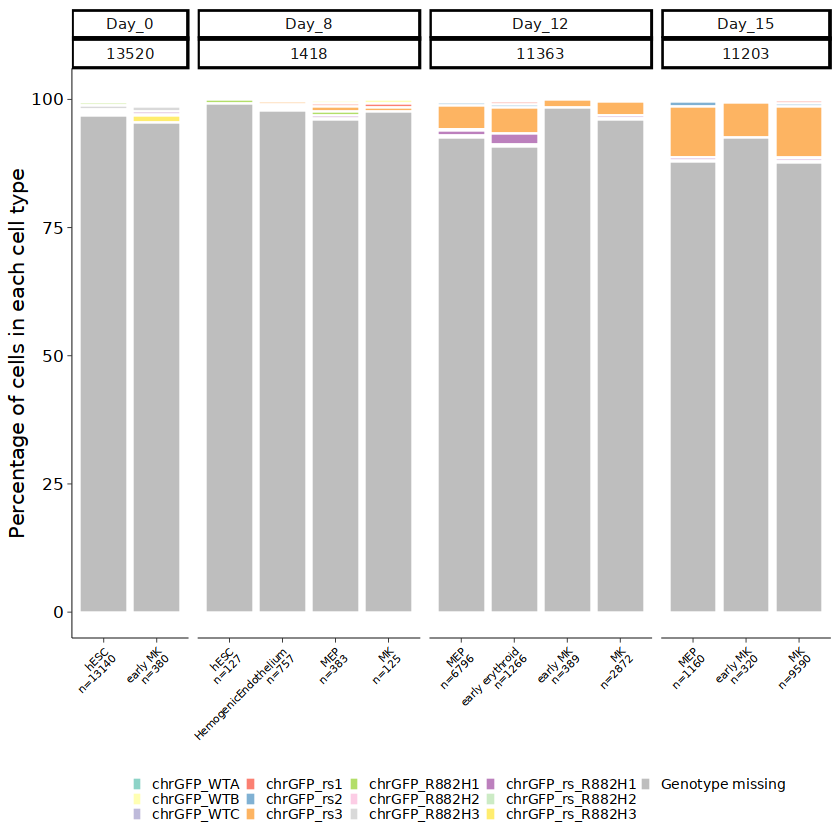

In [80]:
#### Stacked Graph #2---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-Freq.table_filtered %>%
    mutate(myaxis = paste0(current_anot, "\n", "n=", TOTAL), drop=F) %>%
    mutate(myaxis=fct_reorder(myaxis,as.numeric(current_anot)), drop=F) %>%
    ggplot(aes(x=myaxis, y=Perc, fill=Assigned_GFPbc)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cell type",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_clone_lines,
                      drop=F,
                      name="My Annotation")

 stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ time_point+ntime, scales='free_x', space='free_x', switch="y", labeller=labeller(paste0(Freq.table_filtered$time_point, "\n", "n=", Freq.table_filtered$ntime)))+   
    scale_x_discrete(name="Seurat clusters", drop=T)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=6),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=6,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=8, color="black", family="sans"),
                  legend.key.size = unit(0.25, 'cm'), #change legend key size
                  legend.key.height = unit(0.25, 'cm'), #change legend key height
                  legend.key.width = unit(0.25, 'cm'), #change legend key width
                  legend.position="bottom")



stacked_barplot

In [81]:
setwd(path_graphs)

svgname<-paste("stacked_barplot_time_point_current_anot_vs_Assigned_GFPbc",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="png",
        width=12, height=6)
}

## subset for the cells that are genotyped

In [99]:
adata_sub<-subset(adata, Assigned_GFPbc != "Genotype missing")

In [100]:
met<-adata_sub[[]]

In [101]:
colnames(met)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "wsnn_res.0.25"                     "CellTypist_BMA_label"             
[67] "CellTypist_BMA_conf_score"         "CellTypist_IPSCs_label"           
[69] "CellTypist_IPSCs_conf_score"       "CellTypist_BMA_label_filtered"    
[71] "CellTypist_IPSCs_label_filtered"   "time_point"                       
[73] "time"                              "nucleosome_signal"                
[75] "nucleosome_percentile"             "FRiP"                             
[77] "atac_pct_reads_in_peaks"           "my_anot"                          
[79] "FOI"                               "my_anot_updated"                  
[81] "majority_voting_BMA"               "majority_voting_iPSCs"            
[83] "current_anot"

In [102]:
met.dt<-data.table(met,key=c("time_point","current_anot","Assigned_GFPbc"))

In [103]:
#str(met.dt)

In [104]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [105]:
met.dt<-data.table(met, key=c("time_point","current_anot"))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [106]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("time_point","current_anot"))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [107]:
str(Freq.table)

'data.frame':	95 obs. of  6 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 1 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 1 2 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 3 10 ...
 $ TOTAL         : int  17 17 17 17 17 17 17 17 419 419 ...
 $ Perc          : num  5.88 5.88 11.76 5.88 23.53 ...


In [108]:
met.dt<-data.table(met, key=c("time_point"))
Freq.time_point<-as.data.frame(met.dt[,.(ntime=.N),by=key(met.dt)], stringsAsFactors=F)

Freq.table<-merge(Freq.table,
                  Freq.time_point,
                  by="time_point")

#Freq.table

In [109]:
str(Freq.table)

'data.frame':	95 obs. of  7 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 1 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 1 2 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 3 10 ...
 $ TOTAL         : int  17 17 17 17 17 17 17 17 419 419 ...
 $ Perc          : num  5.88 5.88 11.76 5.88 23.53 ...
 $ ntime         : int  436 436 436 436 436 436 436 436 436 436 ...


In [110]:
Freq.TOTAL<-merge(Freq.TOTAL,
                  Freq.time_point,
                  by="time_point")

In [116]:
Freq.table_filtered<-Freq.table[which(Freq.table$TOTAL >= 3),]

str(Freq.table_filtered)

'data.frame':	93 obs. of  7 variables:
 $ time_point    : Ord.factor w/ 4 levels "Day_0"<"Day_8"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ current_anot  : Ord.factor w/ 6 levels "hESC"<"HemogenicEndothelium"<..: 5 5 5 5 5 5 5 5 1 1 ...
 $ Assigned_GFPbc: Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: 3 6 7 8 9 10 11 12 1 2 ...
 $ Freq          : int  1 1 2 1 4 2 1 5 3 10 ...
 $ TOTAL         : int  17 17 17 17 17 17 17 17 419 419 ...
 $ Perc          : num  5.88 5.88 11.76 5.88 23.53 ...
 $ ntime         : int  436 436 436 436 436 436 436 436 436 436 ...


In [117]:
vector_colors_clone_lines<-c(brewer.pal(12, "Set3"),"gray")
vector_colors_clone_lines

[1] "#8DD3C7" "#FFFFB3" "#BEBADA" "#FB8072" "#80B1D3" "#FDB462" "#B3DE69"
 [8] "#FCCDE5" "#D9D9D9" "#BC80BD" "#CCEBC5" "#FFED6F" "gray"

In [118]:
library(forcats)
library(cowplot)

-------------------------------------->	0 25 50 75 100


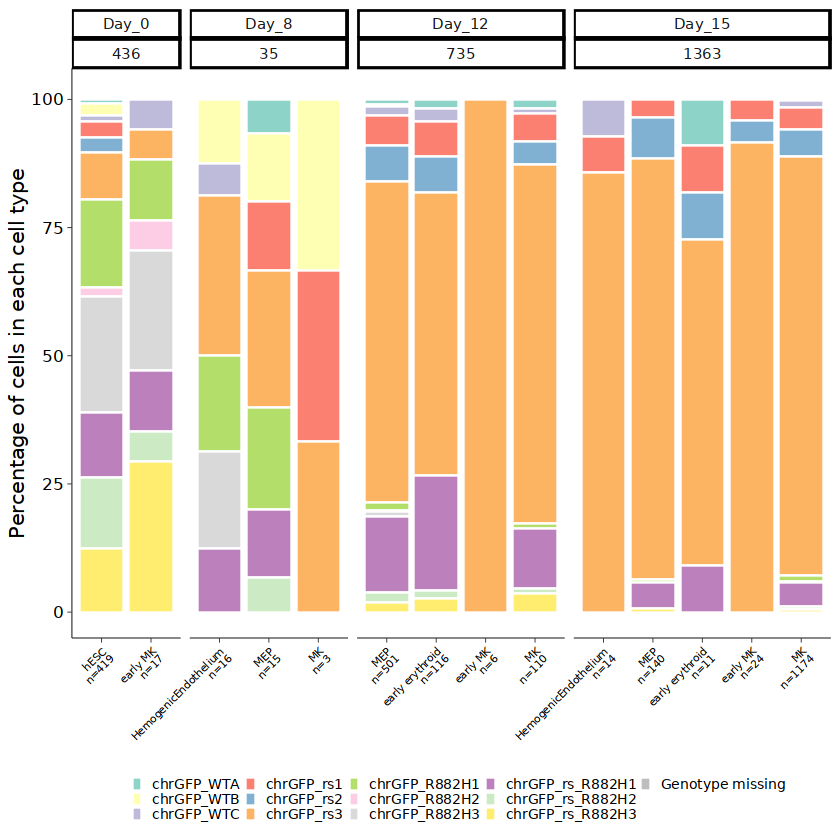

In [119]:
#### Stacked Graph #2---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-Freq.table_filtered %>%
    mutate(myaxis = paste0(current_anot, "\n", "n=", TOTAL), drop=F) %>%
    mutate(myaxis=fct_reorder(myaxis,as.numeric(current_anot)), drop=F) %>%
    ggplot(aes(x=myaxis, y=Perc, fill=Assigned_GFPbc)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cell type",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_clone_lines,
                      drop=F,
                      name="My Annotation")

 stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ time_point+ntime, scales='free_x', space='free_x', switch="y", labeller=labeller(paste0(Freq.table_filtered$time_point, "\n", "n=", Freq.table_filtered$ntime)))+   
    scale_x_discrete(name="Seurat clusters", drop=T)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=6),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=6,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=8, color="black", family="sans"),
                  legend.key.size = unit(0.25, 'cm'), #change legend key size
                  legend.key.height = unit(0.25, 'cm'), #change legend key height
                  legend.key.width = unit(0.25, 'cm'), #change legend key width
                  legend.position="bottom")



stacked_barplot

In [120]:
setwd(path_graphs)

svgname<-paste("stacked_barplot_time_point_current_anot_vs_Assigned_GFPbc_restricted_to_genotyped_cells",".png",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="png",
        width=12, height=6)
}